In [1]:
import sys
print(sys.executable)


/home/leesungwon/miniconda3/envs/eda/bin/python


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

# 현재 정리된 elephant/mice dataset 구조를 로드합니다.
# TrafficGenerator 구조상 실제 payload는 dst_to_src 방향에 있으므로,
# dataset/elephant_dst_to_src 아래의 relabel + parent_flow split 준비본을 사용합니다.

def resolve_dataset_root() -> Path:
    candidates = [
        Path('dataset/elephant_dst_to_src'),
        Path('../dataset/elephant_dst_to_src'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('dataset/elephant_dst_to_src 폴더를 찾지 못했습니다.')


DATASET_ROOT = resolve_dataset_root()
DATASET_NAMES = ['vl2', 'dctcp', 'fb']
SEQ_NAMES = ['seq3', 'seq5', 'seq10']

DATASETS = {
    f'{dataset}_{seq}': DATASET_ROOT / dataset / seq / 'dataset.jsonl'
    for dataset in DATASET_NAMES
    for seq in SEQ_NAMES
}

MASKED_FEATURES = [
    'retransmission',
    'out_of_order',
    'duplicate_ack',
    'fast_retransmission',
]


def load_jsonl_sample(path: Path) -> dict:
    with path.open(encoding='utf-8') as f:
        for line in f:
            if line.strip():
                return json.loads(line)
    raise ValueError(f'{path}에 sample이 없습니다.')


FEATURE_NAMES = load_jsonl_sample(next(iter(DATASETS.values()))).get('feature_names')
if not FEATURE_NAMES:
    raise ValueError('dataset sample에 feature_names가 없습니다.')

PLOT_FEATURE_NAMES = [name for name in FEATURE_NAMES if name != 'direction']
PAYLOAD_FEATURE = 'tcp_len' if 'tcp_len' in FEATURE_NAMES else 'tcp_payload_bytes'
IAT_FEATURE = 'iat_us'


def clamp_seq_len(sample, x):
    raw_seq_len = int(sample.get('seq_len', x.shape[0]))
    return max(1, min(raw_seq_len, x.shape[0]))


def packet_flag_any(valid_x, feature_name: str) -> int:
    if feature_name in FEATURE_NAMES:
        values = valid_x[:, FEATURE_NAMES.index(feature_name)]
        return int((values > 0).any())
    return 0


def load_flow_dataset(path: Path, dataset_key: str):
    traffic_profile, seq_profile = dataset_key.split('_', 1)
    max_packet_count = int(seq_profile.replace('seq', ''))
    meta_rows = []
    packet_rows = []

    with path.open('r', encoding='utf-8') as f:
        for row_id, line in enumerate(f, start=1):
            if not line.strip():
                continue

            sample = json.loads(line)
            sample_feature_names = sample.get('feature_names', FEATURE_NAMES)
            if sample_feature_names != FEATURE_NAMES:
                raise ValueError(f'{path}:{row_id} feature_names가 다른 dataset과 다릅니다.')

            flow_key = sample.get('flow_key', {})
            trace_key = sample.get('trace_key', {})
            x = np.asarray(sample.get('x', []), dtype=float)

            if x.ndim != 2 or x.shape[1] != len(FEATURE_NAMES):
                raise ValueError(f'{path}:{row_id} x shape이 예상과 다릅니다: {x.shape}')

            seq_len = clamp_seq_len(sample, x)
            valid_x = x[:seq_len]
            src_index = flow_key.get('src_index', 0)
            flow_id = flow_key.get('flow_id', flow_key.get('tcp_stream', row_id))
            source_file = flow_key.get('source_file', trace_key.get('source_file', ''))
            tcp_stream = flow_key.get('tcp_stream', trace_key.get('tcp_stream', np.nan))
            direction = flow_key.get('direction', '')
            run_id = sample.get('run_id', '')
            directional_size = sample.get('directional_size_bytes', 0)
            flow_size = sample.get('flow_size_bytes', directional_size)
            label = sample.get('label')

            payload = valid_x[:, FEATURE_NAMES.index(PAYLOAD_FEATURE)]
            iat = valid_x[:, FEATURE_NAMES.index(IAT_FEATURE)] if IAT_FEATURE in FEATURE_NAMES else np.zeros(seq_len)

            meta = {
                'dataset': dataset_key,
                'traffic_profile': traffic_profile,
                'seq_profile': seq_profile,
                'max_packet_count': max_packet_count,
                'row_id': row_id,
                'run_id': run_id,
                'src_index': src_index,
                'flow_id': flow_id,
                'source_file': source_file,
                'tcp_stream': tcp_stream,
                'direction': direction,
                'direction_label': f'{direction} L{label}',
                'directional_size_bytes': directional_size,
                'flow_size_bytes': flow_size,
                'label': label,
                'packet_count': x.shape[0],
                'seq_len': seq_len,
                'padded_packet_count': int(x.shape[0] - seq_len),
                'is_padded_sample': int(seq_len < x.shape[0]),
                'x_mean': float(valid_x.mean()),
                'cum_payload_n': float(payload.sum()),
                'payload_packet_count_n': int((payload > 0).sum()),
                'full_payload_packet_count_n': int((payload >= 1400).sum()),
                'elapsed_iat_us_n': float(iat.sum()),
                'mean_iat_us_n': float(iat.mean()),
                'max_iat_us_n': float(iat.max()),
                'seen_fin_n': packet_flag_any(valid_x, 'tcp_fin'),
                'seen_rst_n': packet_flag_any(valid_x, 'tcp_rst'),
            }

            for col_idx, feature_name in enumerate(FEATURE_NAMES):
                values = valid_x[:, col_idx]
                meta[f'{feature_name}_mean'] = float(values.mean())
                meta[f'{feature_name}_first'] = float(values[0])
                meta[f'{feature_name}_last'] = float(values[-1])
                meta[f'{feature_name}_max'] = float(values.max())

            meta_rows.append(meta)

            for packet_index, values in enumerate(x):
                packet_row = {
                    'dataset': dataset_key,
                    'traffic_profile': traffic_profile,
                    'seq_profile': seq_profile,
                    'max_packet_count': max_packet_count,
                    'row_id': row_id,
                    'run_id': run_id,
                    'flow_id': flow_id,
                    'source_file': source_file,
                    'tcp_stream': tcp_stream,
                    'direction': direction,
                    'direction_label': f'{direction} L{label}',
                    'packet_index': packet_index,
                    'seq_len': seq_len,
                    'is_padding': packet_index >= seq_len,
                    'label': label,
                    'flow_size_bytes': flow_size,
                    'directional_size_bytes': directional_size,
                }
                packet_row.update(dict(zip(FEATURE_NAMES, values)))
                packet_rows.append(packet_row)

    return pd.DataFrame(meta_rows), pd.DataFrame(packet_rows)


loaded = {}
flow_frames = []
packet_frames = []

for dataset_key, dataset_path in DATASETS.items():
    if not dataset_path.exists():
        raise FileNotFoundError(dataset_path)
    flow_df, flow_packet_df = load_flow_dataset(dataset_path, dataset_key)
    loaded[dataset_key] = dataset_path
    flow_frames.append(flow_df)
    packet_frames.append(flow_packet_df)

all_df = pd.concat(flow_frames, ignore_index=True)
all_packet_df = pd.concat(packet_frames, ignore_index=True)
valid_packet_df = all_packet_df[~all_packet_df['is_padding']].copy()
padding_packet_df = all_packet_df[all_packet_df['is_padding']].copy()

print('loaded paths:')
for name, dataset_path in loaded.items():
    print(f'- {name}: {dataset_path}')

print('')
print('feature names:')
print(FEATURE_NAMES)

print('')
print('flow counts by traffic_profile/seq_profile/label:')
print(all_df.groupby(['traffic_profile', 'seq_profile', 'label']).size())
print('')
print('flow counts by direction:')
print(all_df.groupby(['traffic_profile', 'seq_profile', 'direction']).size())

valid_masked_features = [name for name in MASKED_FEATURES if name in valid_packet_df.columns]
if valid_masked_features:
    valid_masked_nonzero = valid_packet_df[valid_masked_features].to_numpy().sum()
    padding_masked_nonzero = padding_packet_df[valid_masked_features].to_numpy().sum() if len(padding_packet_df) else 0
    print(f'\nvalid masked feature nonzero sum: {valid_masked_nonzero:g}')
    print(f'padding masked feature nonzero sum: {padding_masked_nonzero:g}')

summary_cols = [
    'seq_len',
    'padded_packet_count',
    'flow_size_bytes',
    'directional_size_bytes',
    'cum_payload_n',
    'elapsed_iat_us_n',
]
display(all_df.groupby(['traffic_profile', 'seq_profile'])[summary_cols].agg(['count', 'mean', 'median', 'min', 'max']))
display(all_df.head())


loaded paths:
- vl2_seq3: ../dataset/elephant_dst_to_src/vl2/seq3/dataset.jsonl
- vl2_seq5: ../dataset/elephant_dst_to_src/vl2/seq5/dataset.jsonl
- vl2_seq10: ../dataset/elephant_dst_to_src/vl2/seq10/dataset.jsonl
- dctcp_seq3: ../dataset/elephant_dst_to_src/dctcp/seq3/dataset.jsonl
- dctcp_seq5: ../dataset/elephant_dst_to_src/dctcp/seq5/dataset.jsonl
- dctcp_seq10: ../dataset/elephant_dst_to_src/dctcp/seq10/dataset.jsonl
- fb_seq3: ../dataset/elephant_dst_to_src/fb/seq3/dataset.jsonl
- fb_seq5: ../dataset/elephant_dst_to_src/fb/seq5/dataset.jsonl
- fb_seq10: ../dataset/elephant_dst_to_src/fb/seq10/dataset.jsonl

feature names:
['direction', 'frame_len', 'ip_len', 'ip_hdr_len', 'ip_ttl', 'ip_dscp', 'ip_ecn', 'tcp_len', 'tcp_hdr_len', 'tcp_syn', 'tcp_ack', 'tcp_psh', 'tcp_fin', 'tcp_rst', 'tcp_window_size', 'iat_us', 'elapsed_us', 'cum_payload_bytes']

flow counts by traffic_profile/seq_profile/label:
traffic_profile  seq_profile  label
dctcp            seq10        0        14399
     

seq_len                           \
                              count      mean median min max   
traffic_profile seq_profile                                    
dctcp           seq10         16000  9.316437   10.0   2  10   
                seq3          16000  2.984688    3.0   2   3   
                seq5          16000  4.896063    5.0   2   5   
fb              seq10         16000  2.141062    2.0   1  10   
                seq3          16000  2.052875    2.0   1   3   
                seq5          16000  2.095813    2.0   1   5   
vl2             seq10          3200  4.488437    3.0   1  10   
                seq3           3200  2.570625    3.0   1   3   
                seq5           3200  3.272813    3.0   1   5   

                            padded_packet_count                      ...  \
                                          count mean median min max  ...   
traffic_profile seq_profile                                          ...   
dctcp           seq10                     16000  0.0    0.0   0   0  ...   
                seq3                      16000  0.0    0.0   0   0  ...   
                seq5                      16000  0.0    0.0   0   0  ...   
fb              seq10                     16000  0.0    0.0   0   0  ...   
                seq3                      16000  0.0    0.0   0   0  ...   
                seq5                      16000  0.0    0.0   0   0  ...   
vl2             seq10                      3200  0.0    0.0   0   0  ...   
                seq3                       3200  0.0    0.0   0   0  ...   
                seq5                       3200  0.0    0.0   0   0  ...   

                            cum_payload_n                               \
                                    count          mean   median   min   
traffic_profile seq_profile                                              
dctcp           seq10               16000  11517.330500  13052.0  23.0   
                seq3                16000   2495.773438   2916.0  23.0   
                seq5                16000   5219.312125   5812.0  23.0   
fb              seq10               16000    352.245625    101.0  20.0   
                seq3                16000    241.908062    100.5  20.0   
                seq5                16000    294.559188    101.0  20.0   
vl2             seq10                3200   4100.196563   1322.5  20.0   
                seq3                 3200   1493.689687   1273.0  20.0   
                seq5                 3200   2402.521563   1322.5  20.0   

                                     elapsed_iat_us_n                         \
                                 max            count           mean  median   
traffic_profile seq_profile                                                    
dctcp           seq10        13052.0            16000  143013.716375  1226.0   
                seq3          2916.0            16000    3440.304813    18.0   
                seq5          5812.0            16000   15208.565750    27.0   
fb              seq10        13052.0            16000     759.804313    15.0   
                seq3          2916.0            16000     740.137625    15.0   
                seq5          5812.0            16000     744.280375    15.0   
vl2             seq10        13052.0             3200    6219.688125    21.0   
                seq3          2916.0             3200    2438.852188    15.0   
                seq5          5812.0             3200    4001.871250    18.0   

                                             
                             min        max  
traffic_profile seq_profile                  
dctcp           seq10        1.0  3325958.0  
                seq3         1.0  1160401.0  
                seq5         1.0  1981517.0  
fb              seq10        0.0    28621.0  
                seq3         0.0    28621.0  
                seq5         0.0    28621.0  
vl2             seq10        0.0   295985.0  
                seq3         0.0   2

,dataset,traffic_profile,seq_profile,max_packet_count,row_id,run_id,src_index,flow_id,source_file,tcp_stream,...,iat_us_last,iat_us_max,elapsed_us_mean,elapsed_us_first,elapsed_us_last,elapsed_us_max,cum_payload_bytes_mean,cum_payload_bytes_first,cum_payload_bytes_last,cum_payload_bytes_max
0,vl2_seq3,vl2,seq3,3,1,mininet_vl2_l10,5,4,,NaN,...,18.0,18.0,18.000000,0.0,36.0,36.0,496.000000,0.0,1468.0,1468.0
1,vl2_seq3,vl2,seq3,3,2,mininet_vl2_l10,3,2,,NaN,...,15.0,25.0,21.666667,0.0,40.0,40.0,496.000000,0.0,1468.0,1468.0
2,vl2_seq3,vl2,seq3,3,3,mininet_vl2_l10,3,3,,NaN,...,12.0,12.0,12.000000,0.0,24.0,24.0,354.666667,0.0,1044.0,1044.0
3,vl2_seq3,vl2,seq3,3,4,mininet_vl2_l10,4,3,,NaN,...,16.0,16.0,12.000000,0.0,26.0,26.0,496.000000,0.0,1468.0,1468.0
4,vl2_seq3,vl2,seq3,3,5,mininet_vl2_l10,6,7,,NaN,...,13.0,13.0,11.000000,0.0,23.0,23.0,224.000000,0.0,652.0,652.0


In [3]:
# dst_to_src 전용 dataset / seq_len-aware sanity checks
print('dataset files:')
for name, path in loaded.items():
    print(f'- {name}: {path}')

print('\nshape and seq_len checks:')
shape_summary = all_df.groupby(['traffic_profile', 'seq_profile']).agg(
    samples=('row_id', 'count'),
    packet_count_min=('packet_count', 'min'),
    packet_count_max=('packet_count', 'max'),
    seq_len_min=('seq_len', 'min'),
    seq_len_median=('seq_len', 'median'),
    seq_len_mean=('seq_len', 'mean'),
    seq_len_max=('seq_len', 'max'),
    padded_sample_rate=('is_padded_sample', 'mean'),
)
display(shape_summary)

bad_seq = all_df[(all_df['seq_len'] < 1) | (all_df['seq_len'] > all_df['packet_count'])]
print(f'bad seq_len rows: {len(bad_seq)}')

print('\nseq_len distribution by traffic_profile/seq_profile/label:')
display(
    all_df
    .groupby(['traffic_profile', 'seq_profile', 'label', 'seq_len'])
    .size()
    .rename('count')
    .reset_index()
    .pivot_table(index=['traffic_profile', 'seq_profile', 'label'], columns='seq_len', values='count', fill_value=0)
)

print('\nNaN / inf checks on valid packets only:')
valid_values = valid_packet_df[FEATURE_NAMES].to_numpy(dtype=float)
print('nan count:', int(np.isnan(valid_values).sum()))
print('inf count:', int(np.isinf(valid_values).sum()))

print('\nfeature zero-rate on valid packets:')
zero_rate = (
    valid_packet_df
    .groupby(['traffic_profile', 'seq_profile'])[PLOT_FEATURE_NAMES]
    .agg(lambda s: float((s == 0).mean()))
    .T
    .sort_index()
)
display(zero_rate)

print('\nflow_size duplicate / concentration check:')
dup_rows = []
for (traffic_profile, seq_profile), df in all_df.groupby(['traffic_profile', 'seq_profile']):
    counts = df['flow_size_bytes'].value_counts()
    dup_rows.append({
        'traffic_profile': traffic_profile,
        'seq_profile': seq_profile,
        'samples': len(df),
        'unique_flow_size_bytes': int(counts.size),
        'duplicate_sample_rate': float(1 - counts.size / len(df)),
        'top_size_count': int(counts.iloc[0]),
        'top_size_ratio': float(counts.iloc[0] / len(df)),
        'top_size_bytes': float(counts.index[0]),
    })
display(pd.DataFrame(dup_rows))

print('\ntop repeated flow_size_bytes by traffic profile (seq10 기준):')
for traffic_profile, df in all_df[all_df['seq_profile'] == 'seq10'].groupby('traffic_profile'):
    print(f'[{traffic_profile}]')
    display(df['flow_size_bytes'].value_counts().head(10).rename_axis('flow_size_bytes').reset_index(name='count'))



print('\nparent_flow split files:')
split_rows = []
for dataset_key, dataset_path in DATASETS.items():
    split_dir = dataset_path.parent / 'splits_parent_flow'
    traffic_profile, seq_profile = dataset_key.split('_', 1)
    for split_name in ['train', 'val', 'test']:
        split_path = split_dir / f'{split_name}.jsonl'
        labels = {0: 0, 1: 0}
        count = 0
        if split_path.exists():
            with split_path.open(encoding='utf-8') as f:
                for line in f:
                    if not line.strip():
                        continue
                    sample = json.loads(line)
                    label = int(sample.get('label', 0))
                    labels[label] = labels.get(label, 0) + 1
                    count += 1
        split_rows.append({
            'traffic_profile': traffic_profile,
            'seq_profile': seq_profile,
            'split': split_name,
            'samples': count,
            'label0': labels.get(0, 0),
            'label1': labels.get(1, 0),
            'pos_rate': labels.get(1, 0) / count if count else 0.0,
            'path': str(split_path),
        })

display(pd.DataFrame(split_rows))

print('\nfeature domain summary, valid packets only:')
feature_domain = valid_packet_df.groupby(['traffic_profile', 'seq_profile'])[PLOT_FEATURE_NAMES].agg(['mean', 'median', 'std', 'min', 'max'])
display(feature_domain)


dataset files:
- vl2_seq3: ../dataset/elephant_dst_to_src/vl2/seq3/dataset.jsonl
- vl2_seq5: ../dataset/elephant_dst_to_src/vl2/seq5/dataset.jsonl
- vl2_seq10: ../dataset/elephant_dst_to_src/vl2/seq10/dataset.jsonl
- dctcp_seq3: ../dataset/elephant_dst_to_src/dctcp/seq3/dataset.jsonl
- dctcp_seq5: ../dataset/elephant_dst_to_src/dctcp/seq5/dataset.jsonl
- dctcp_seq10: ../dataset/elephant_dst_to_src/dctcp/seq10/dataset.jsonl
- fb_seq3: ../dataset/elephant_dst_to_src/fb/seq3/dataset.jsonl
- fb_seq5: ../dataset/elephant_dst_to_src/fb/seq5/dataset.jsonl
- fb_seq10: ../dataset/elephant_dst_to_src/fb/seq10/dataset.jsonl

shape and seq_len checks:


samples  packet_count_min  packet_count_max  \
traffic_profile seq_profile                                                
dctcp           seq10          16000                 2                10   
                seq3           16000                 2                 3   
                seq5           16000                 2                 5   
fb              seq10          16000                 1                10   
                seq3           16000                 1                 3   
                seq5           16000                 1                 5   
vl2             seq10           3200                 1                10   
                seq3            3200                 1                 3   
                seq5            3200                 1                 5   

                             seq_len_min  seq_len_median  seq_len_mean  \
traffic_profile seq_profile                                              
dctcp           seq10                  2            10.0      9.316437   
                seq3                   2             3.0      2.984688   
                seq5                   2             5.0      4.896063   
fb              seq10                  1             2.0      2.141062   
                seq3                   1             2.0      2.052875   
                seq5                   1             2.0      2.095813   
vl2             seq10                  1             3.0      4.488437   
                seq3                   1             3.0      2.570625   
                seq5                   1             3.0      3.272813   

                             seq_len_max  padded_sample_rate  
traffic_profile seq_profile                                   
dctcp           seq10                 10                 0.0  
                seq3                   3                 0.0  
                seq5                   5                 0.0  
fb              seq10                 10                 0.0  
                seq3                   3                 0.0  
                seq5                   5                 0.0  
vl2             seq10                 10                 0.0  
                seq3                   3                 0.0  
                seq5                   5                 0.0

bad seq_len rows: 0

seq_len distribution by traffic_profile/seq_profile/label:


seq_len                                1        2        3      4        5   \
traffic_profile seq_profile label                                             
dctcp           seq10       0         0.0    245.0    304.0  320.0    310.0   
                            1         0.0      0.0      0.0    0.0      0.0   
                seq3        0         0.0    245.0  14154.0    0.0      0.0   
                            1         0.0      0.0   1601.0    0.0      0.0   
                seq5        0         0.0    245.0    304.0  320.0  13530.0   
                            1         0.0      0.0      0.0    0.0   1601.0   
fb              seq10       0      1288.0  11643.0   1452.0   15.0      0.0   
                            1         0.0    935.0    290.0   82.0     76.0   
                seq3        0      1288.0  11643.0   1467.0    0.0      0.0   
                            1         0.0    935.0    667.0    0.0      0.0   
                seq5        0      1288.0  11643.0   1452.0   15.0      0.0   
                            1         0.0    935.0    290.0   82.0    295.0   
vl2             seq10       0         2.0   1370.0    590.0  229.0     96.0   
                            1         0.0      0.0      0.0    0.0      0.0   
                seq3        0         2.0   1370.0   1507.0    0.0      0.0   
                            1         0.0      0.0    321.0    0.0      0.0   
                seq5        0         2.0   1370.0    590.0  229.0    688.0   
                            1         0.0      0.0      0.0    0.0    321.0   

seq_len                               6      7      8      9        10  
traffic_profile seq_profile label                                       
dctcp           seq10       0      357.0  358.0  350.0  177.0  11978.0  
                            1        0.0    0.0    0.0    0.0   1601.0  
                seq3        0        0.0    0.0    0.0    0.0      0.0  
                            1        0.0    0.0    0.0    0.0      0.0  
                seq5        0        0.0    0.0    0.0    0.0      0.0  
                            1        0.0    0.0    0.0    0.0      0.0  
fb              seq10       0        0.0    0.0    0.0    0.0      0.0  
                            1       36.0   44.0   39.0   17.0     83.0  
                seq3        0        0.0    0.0    0.0    0.0      0.0  
                            1        0.0    0.0    0.0    0.0      0.0  
                seq5        0        0.0    0.0    0.0    0.0      0.0  
                            1        0.0    0.0    0.0    0.0      0.0  
vl2             seq10       0       81.0   74.0   55.0   19.0    363.0  
                            1        0.0    0.0    0.0    0.0    321.0  
                seq3        0        0.0    0.0    0.0    0.0      0.0  
                            1        0.0    0.0    0.0    0.0      0.0  
                seq5        0        0.0    0.0    0.0    0.0      0.0  
                            1        0.0    0.0    0.0    0.0      0.0


NaN / inf checks on valid packets only:
nan count: 0
inf count: 0

feature zero-rate on valid packets:


...

,flow_size_bytes,count
0,206,15
1,216,13
2,200,12
3,212,11
4,220,10
5,213,10
6,230,9
7,229,9
8,225,9
9,214,9



parent_flow split files:


,traffic_profile,seq_profile,split,samples,label0,label1,pos_rate,path
0,vl2,seq3,train,2240,2013,227,0.101339,../dataset/elephant_dst_to_src/vl2/seq3/splits...
1,vl2,seq3,val,480,437,43,0.089583,../dataset/elephant_dst_to_src/vl2/seq3/splits...
2,vl2,seq3,test,480,429,51,0.106250,../dataset/elephant_dst_to_src/vl2/seq3/splits...
3,vl2,seq5,train,2240,2013,227,0.101339,../dataset/elephant_dst_to_src/vl2/seq5/splits...
4,vl2,seq5,val,480,437,43,0.089583,../dataset/elephant_dst_to_src/vl2/seq5/splits...
5,vl2,seq5,test,480,429,51,0.106250,../dataset/elephant_dst_to_src/vl2/seq5/splits...
6,vl2,seq10,train,2240,2013,227,0.101339,../dataset/elephant_dst_to_src/vl2/seq10/split...
7,vl2,seq10,val,480,437,43,0.089583,../dataset/elephant_dst_to_src/vl2/seq10/split...
8,vl2,seq10,test,480,429,51,0.106250,../dataset/elephant_dst_to_src/vl2/seq10/split...
9,dctcp,seq3,train,11200,10045,1155,0.103125,../dataset/elephant_dst_to_src/dctcp/seq3/spli...



feature domain summary, valid packets only:


frame_len                                    \
                                    mean  median         std   min     max   
traffic_profile seq_profile                                                  
dctcp           seq10        1302.262091  1514.0  501.774732  66.0  1514.0   
                seq3          902.194807  1514.0  705.225919  66.0  1514.0   
                seq5         1132.033854  1514.0  628.632674  66.0  1514.0   
fb              seq10         230.519076    86.0  353.627687  66.0  1514.0   
                seq3          183.838671    86.0  265.366534  66.0  1514.0   
                seq5          206.546536    86.0  312.095038  66.0  1514.0   
vl2             seq10         979.513681  1514.0  645.470493  66.0  1514.0   
                seq3          647.063822   254.0  634.925616  66.0  1514.0   
                seq5          800.097298   787.0  659.185010  66.0  1514.0   

                                  ip_len                                    \
                                    mean  median         std   min     max   
traffic_profile seq_profile                                                  
dctcp           seq10        1288.262091  1500.0  501.774732  52.0  1500.0   
                seq3          888.194807  1500.0  705.225919  52.0  1500.0   
                seq5         1118.033854  1500.0  628.632674  52.0  1500.0   
fb              seq10         216.519076    72.0  353.627687  52.0  1500.0   
                seq3          169.838671    72.0  265.366534  52.0  1500.0   
                seq5          192.546536    72.0  312.095038  52.0  1500.0   
vl2             seq10         965.513681  1500.0  645.470493  52.0  1500.0   
                seq3          633.063822   240.0  634.925616  52.0  1500.0   
                seq5          786.097298   773.0  659.185010  52.0  1500.0   

                             ...    elapsed_us                             \
                             ...          mean median            std  min   
traffic_profile seq_profile  ...                                            
dctcp           seq10        ...  49866.896916   31.0  150650.586098  0.0   
                seq3         ...   1159.922417   12.0   25686.032046  0.0   
                seq5         ...   5201.155303   17.0   53573.368231  0.0   
fb              seq10        ...    477.619523    7.0    1831.685301  0.0   
                seq3         ...    455.705078    6.0    1781.153334  0.0   
                seq5         ...    460.008917    6.0    1809.450470  0.0   
vl2             seq10        ...   1940.357168   18.0   13858.141327  0.0   
                seq3         ...    952.388403   10.0   10757.372575  0.0   
                seq5         ...   1319.116299   13.0   12633.277589  0.0   

                                       cum_payload_bytes                       \
                                   max              mean  median          std   
traffic_profile seq_profile                                                     
dctcp           seq10        3325958.0       5931.241448  5812.0  4120.514791   
                seq3         1160401.0       1201.574474  1468.0  1151.061026   
                seq5         1981517.0       2556.789282  2916.0  2014.433284   
fb              seq10          28621.0        418.168929    20.0  1477.864204   
                seq3           28621.0        147.057602    20.0   377.607937   
                seq5           28621.0        234.115945    20.0   729.087515   
vl2             seq10         295985.0       3792.813966  1944.0  4065.324055   
                seq3          295985.0        826.113421   218.0   994.229217   
                seq5          295985.0       1616.856870  1079.0  1841.951792   

                                           
                             min      max  
traffic_profile seq_profile                
dctcp           seq10        0.0  13052.0  
                seq3         0.0   2916.0  
                seq5         0.0   5812

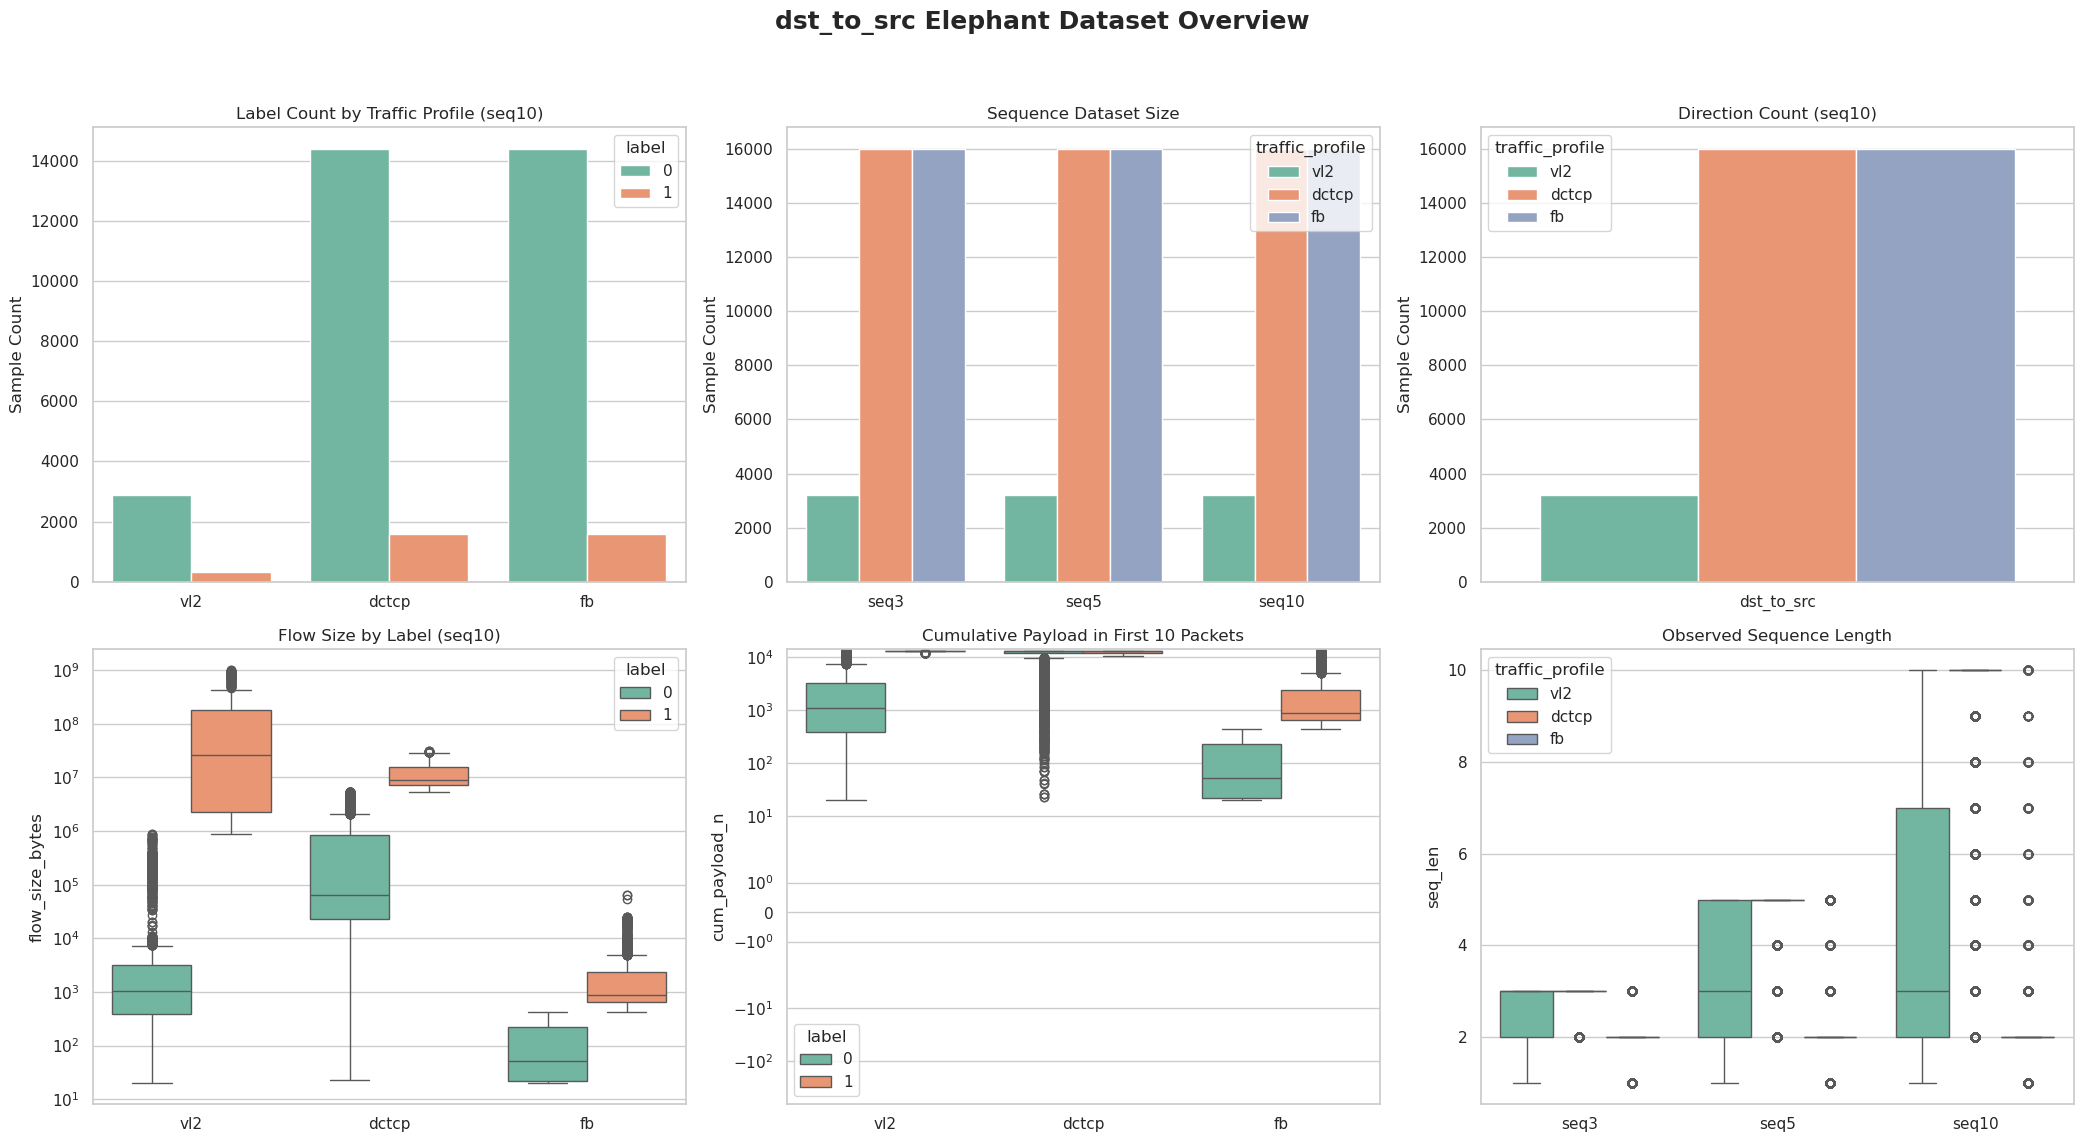

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

seq10_df = all_df[all_df['seq_profile'] == 'seq10'].copy()

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle('dst_to_src Elephant Dataset Overview', fontsize=18, fontweight='bold')

sns.countplot(x='traffic_profile', hue='label', data=seq10_df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Label Count by Traffic Profile (seq10)')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Sample Count')

sns.countplot(x='seq_profile', hue='traffic_profile', data=all_df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Sequence Dataset Size')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Sample Count')

sns.countplot(x='direction', hue='traffic_profile', data=seq10_df, ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Direction Count (seq10)')
axes[0, 2].set_xlabel('')
axes[0, 2].set_ylabel('Sample Count')

sns.boxplot(x='traffic_profile', y='flow_size_bytes', hue='label', data=seq10_df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Flow Size by Label (seq10)')
axes[1, 0].set_xlabel('')

sns.boxplot(x='traffic_profile', y='cum_payload_n', hue='label', data=seq10_df, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_yscale('symlog')
axes[1, 1].set_title('Cumulative Payload in First 10 Packets')
axes[1, 1].set_xlabel('')

sns.boxplot(x='seq_profile', y='seq_len', hue='traffic_profile', data=all_df, ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Observed Sequence Length')
axes[1, 2].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


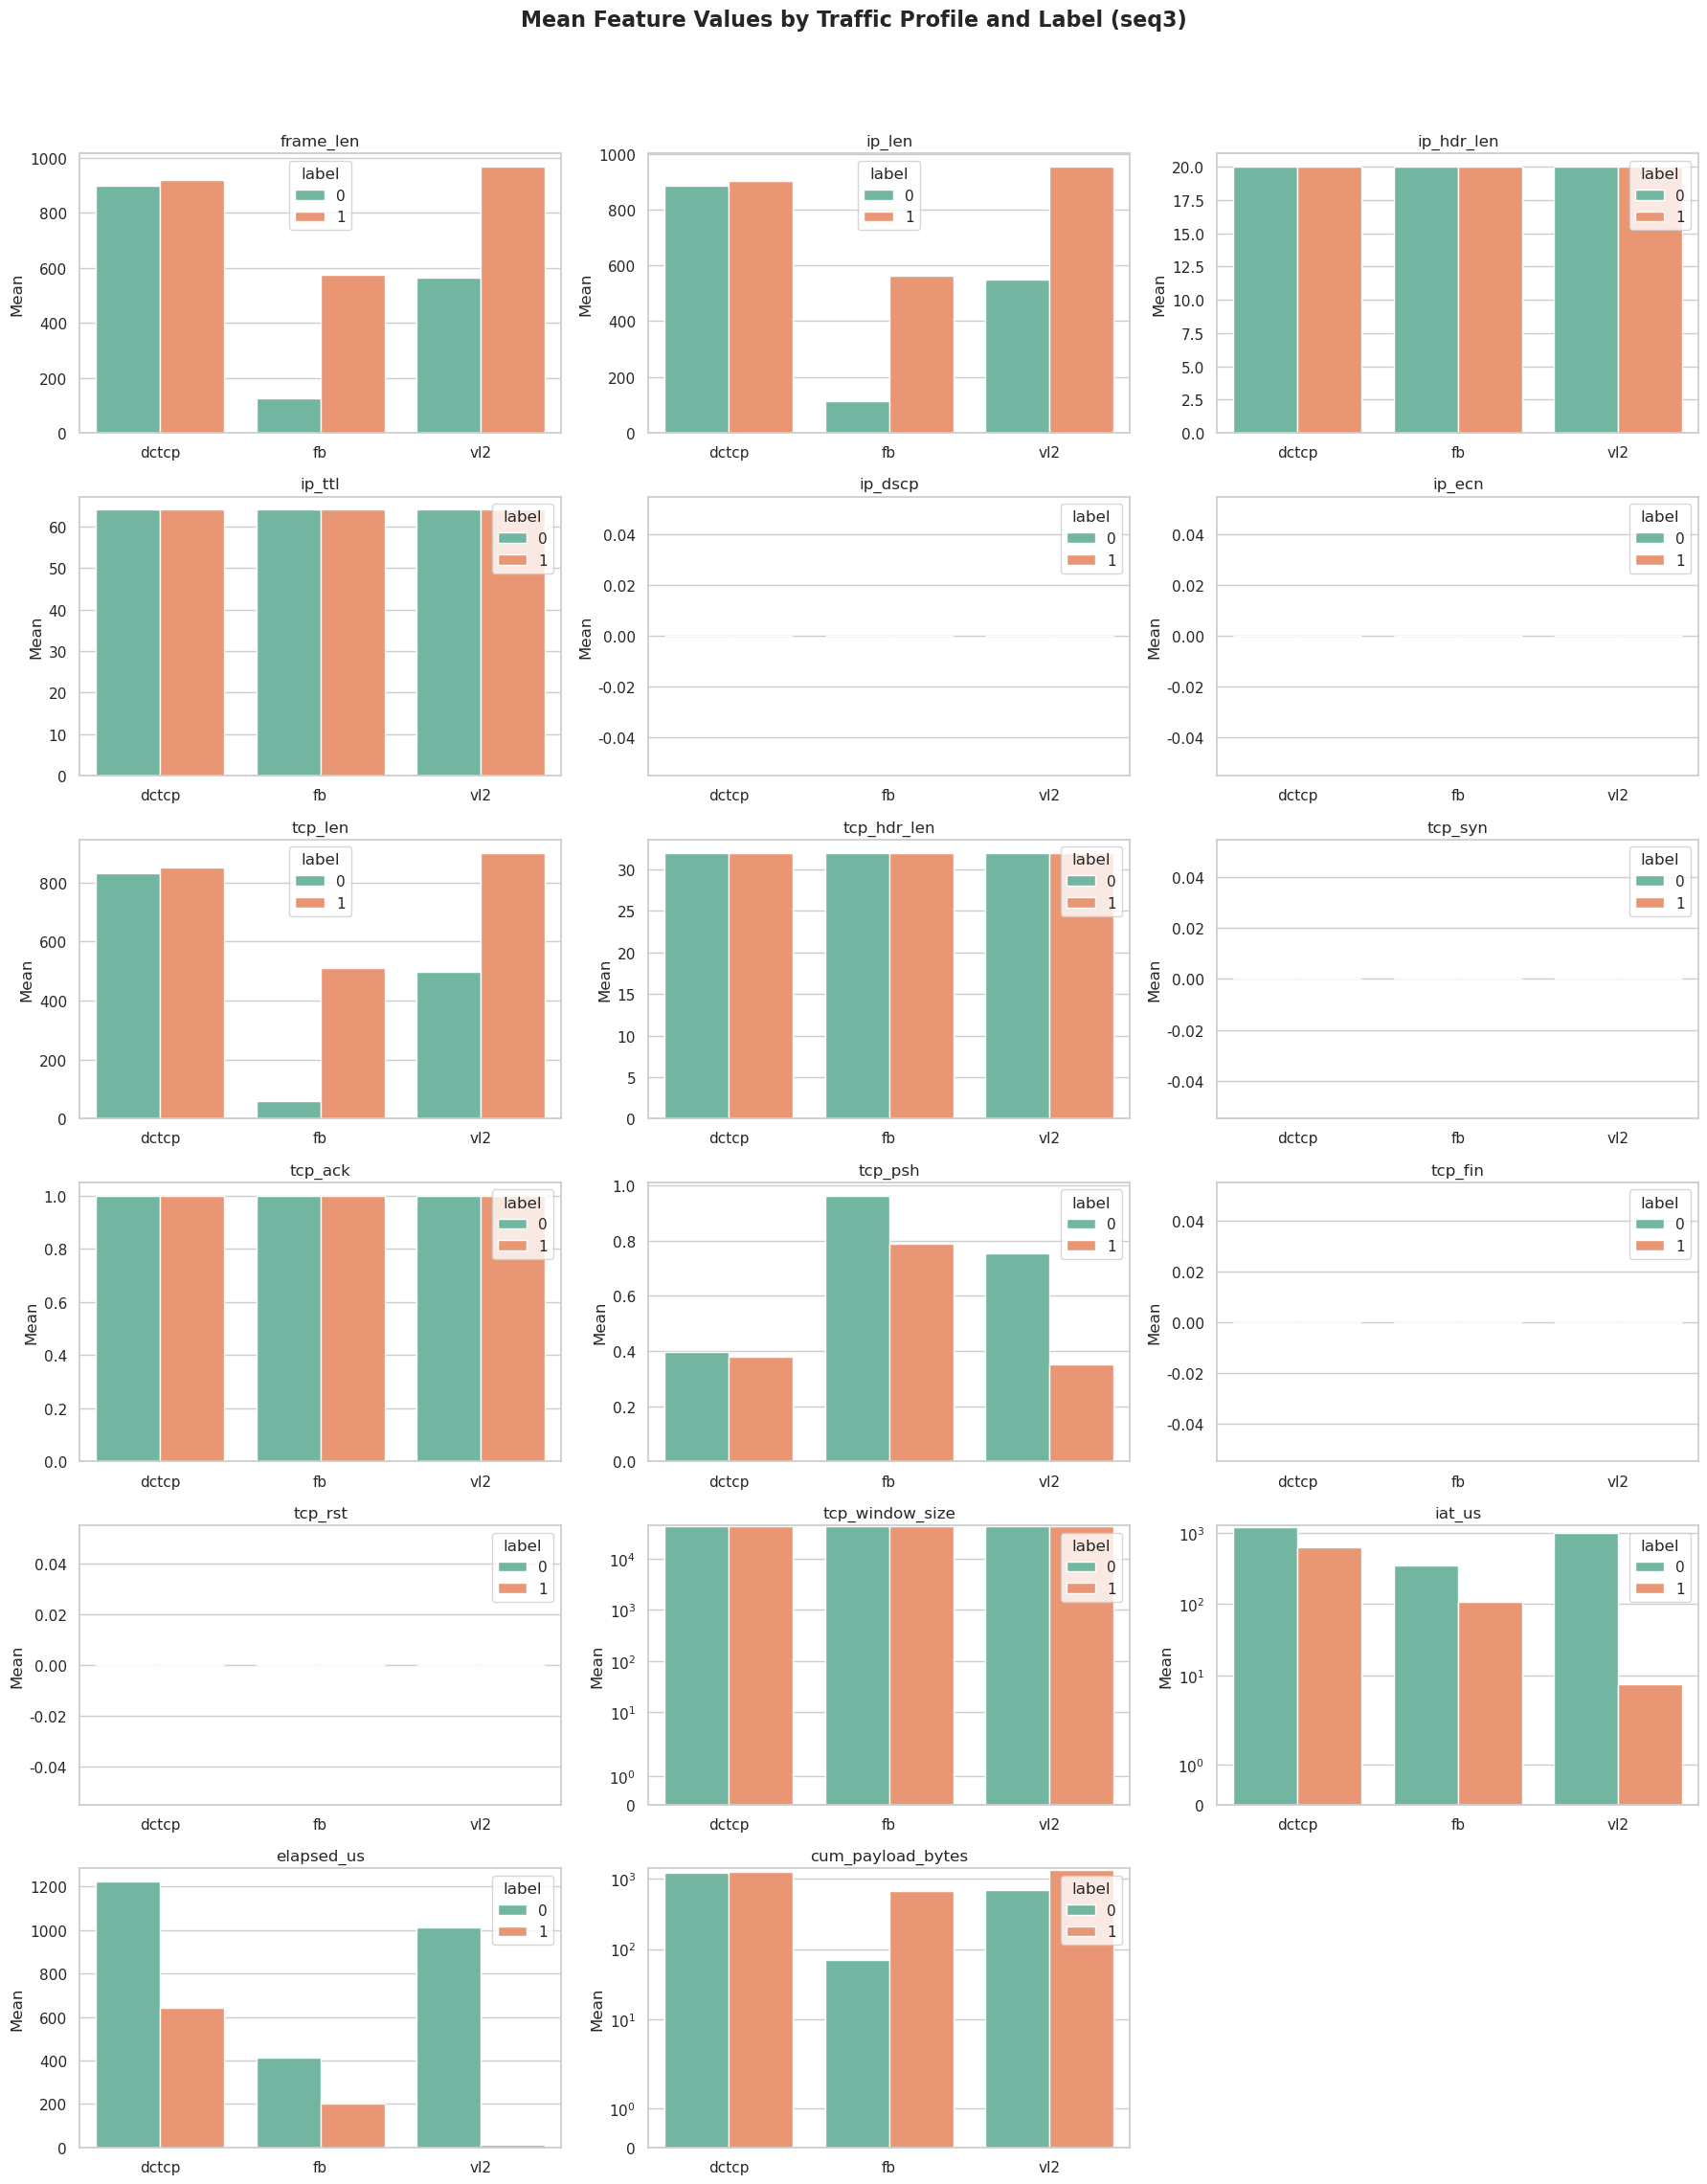

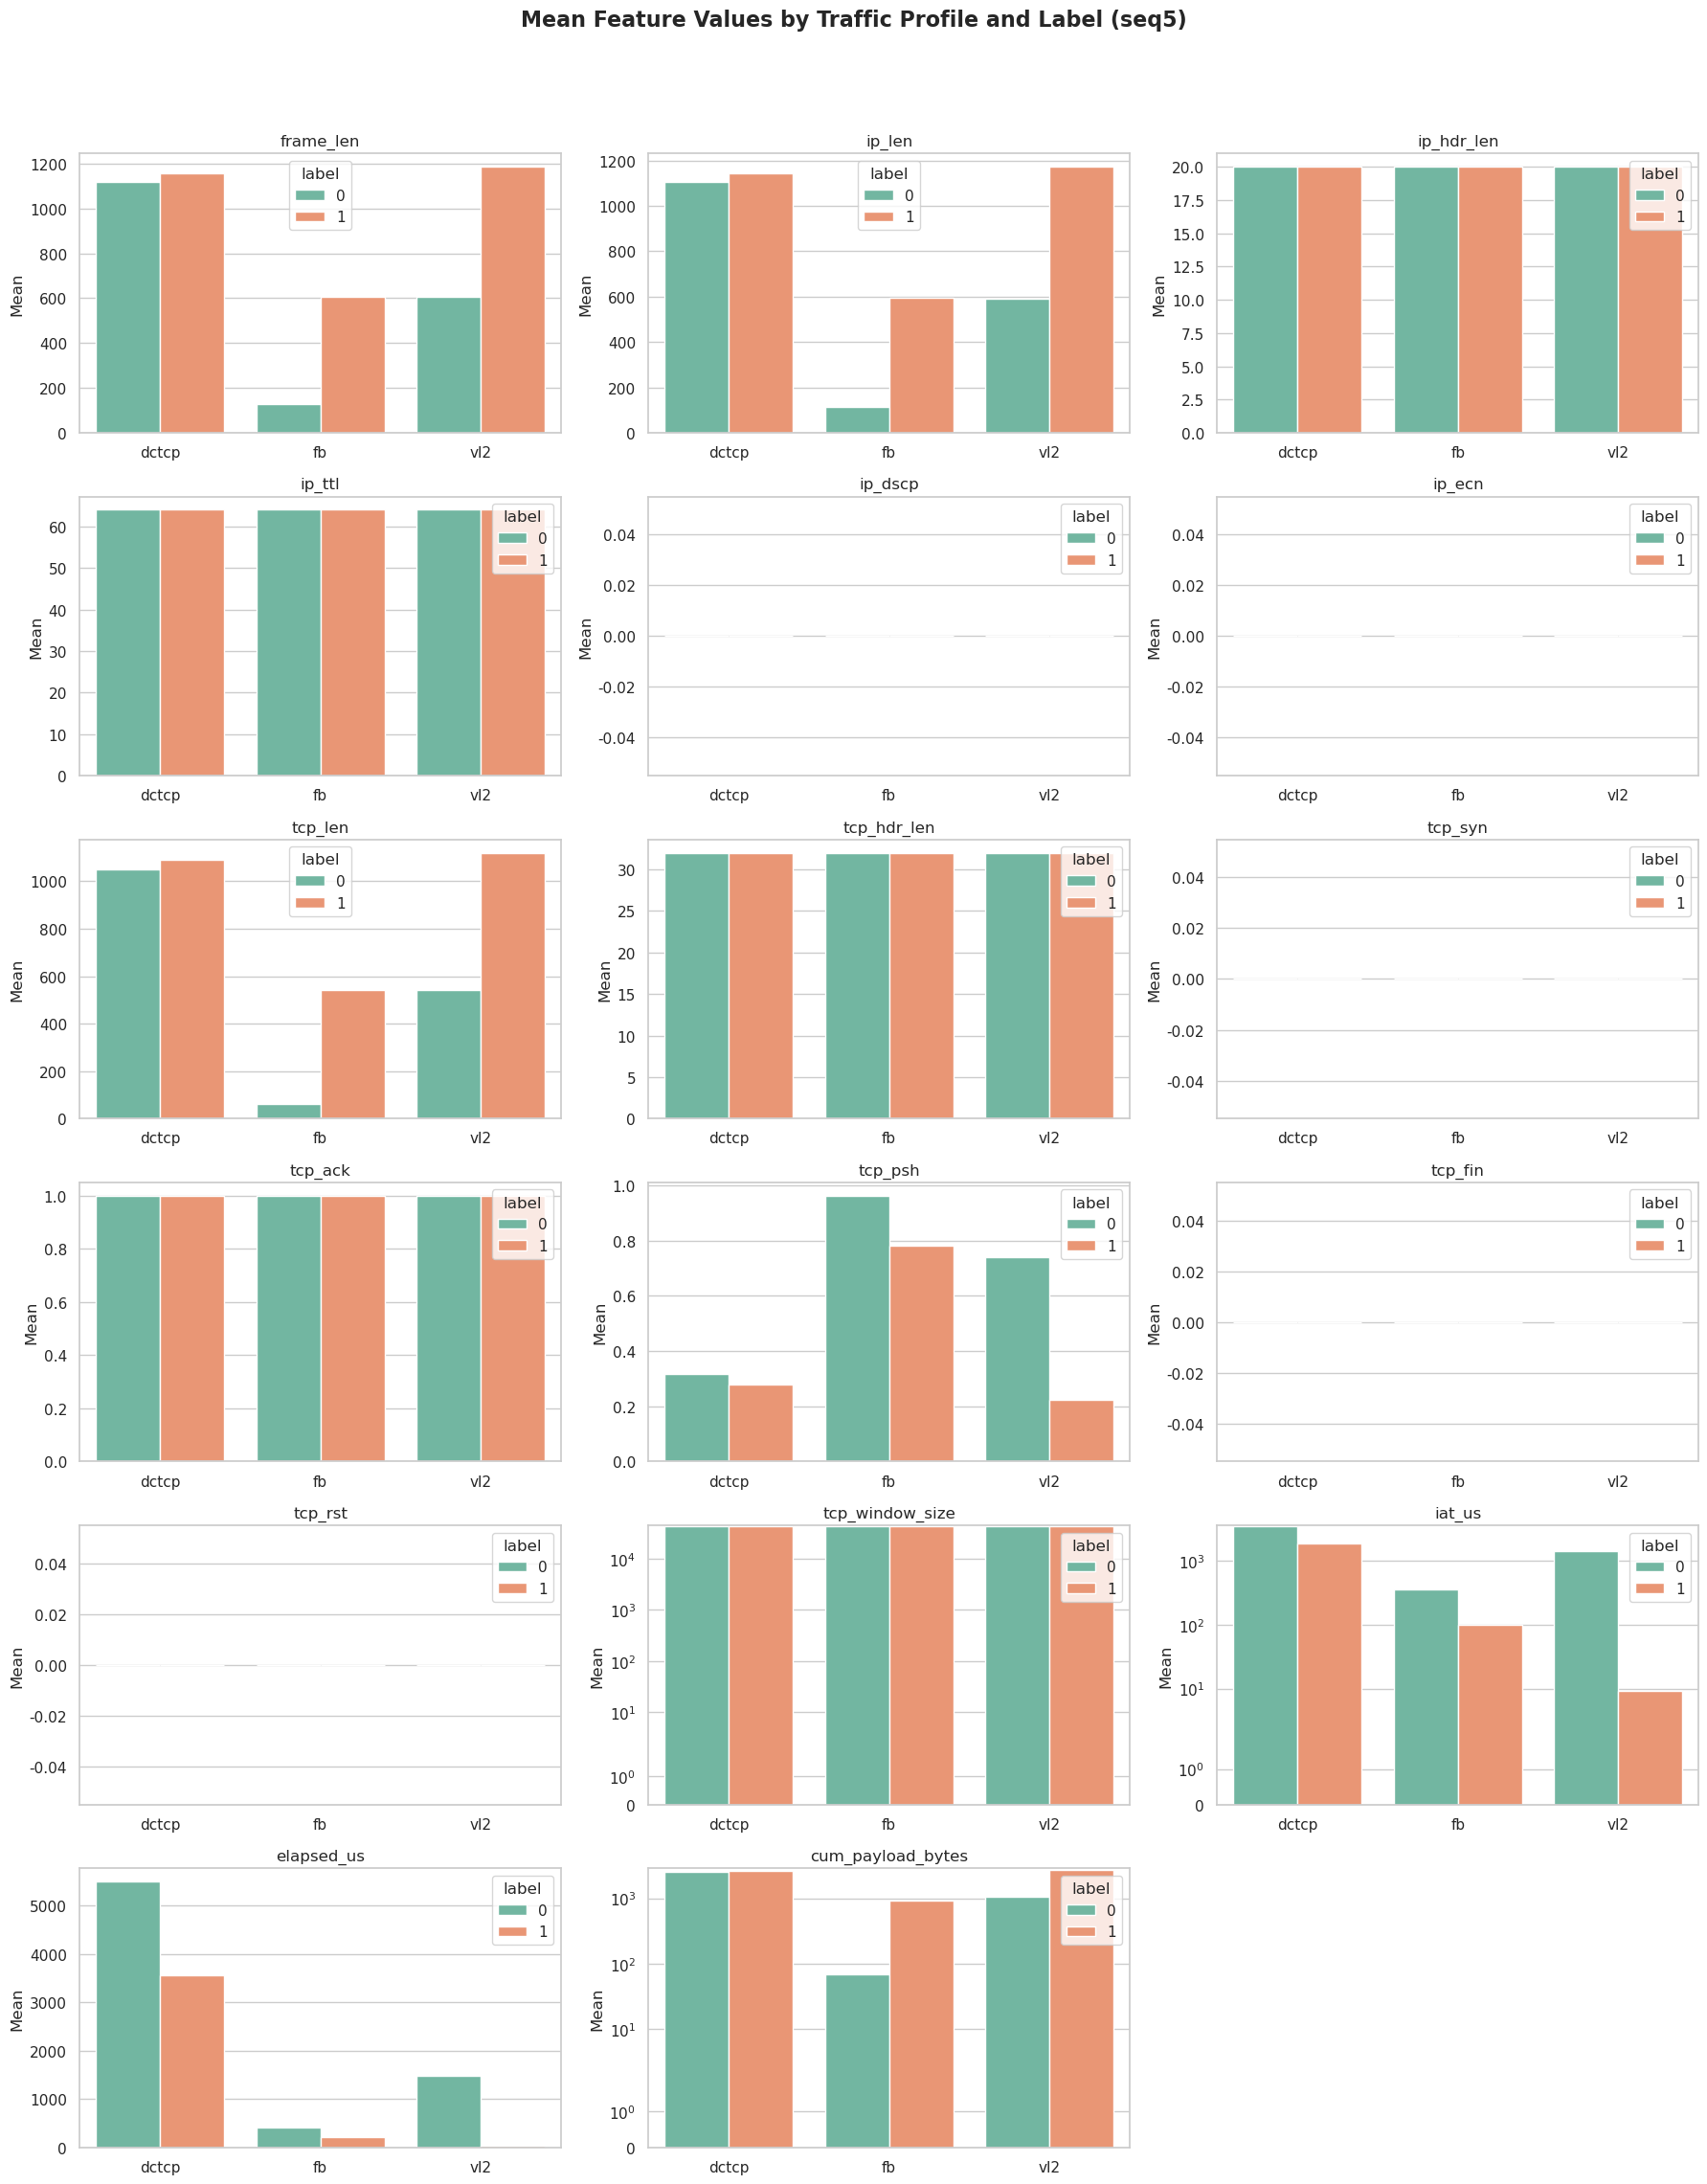

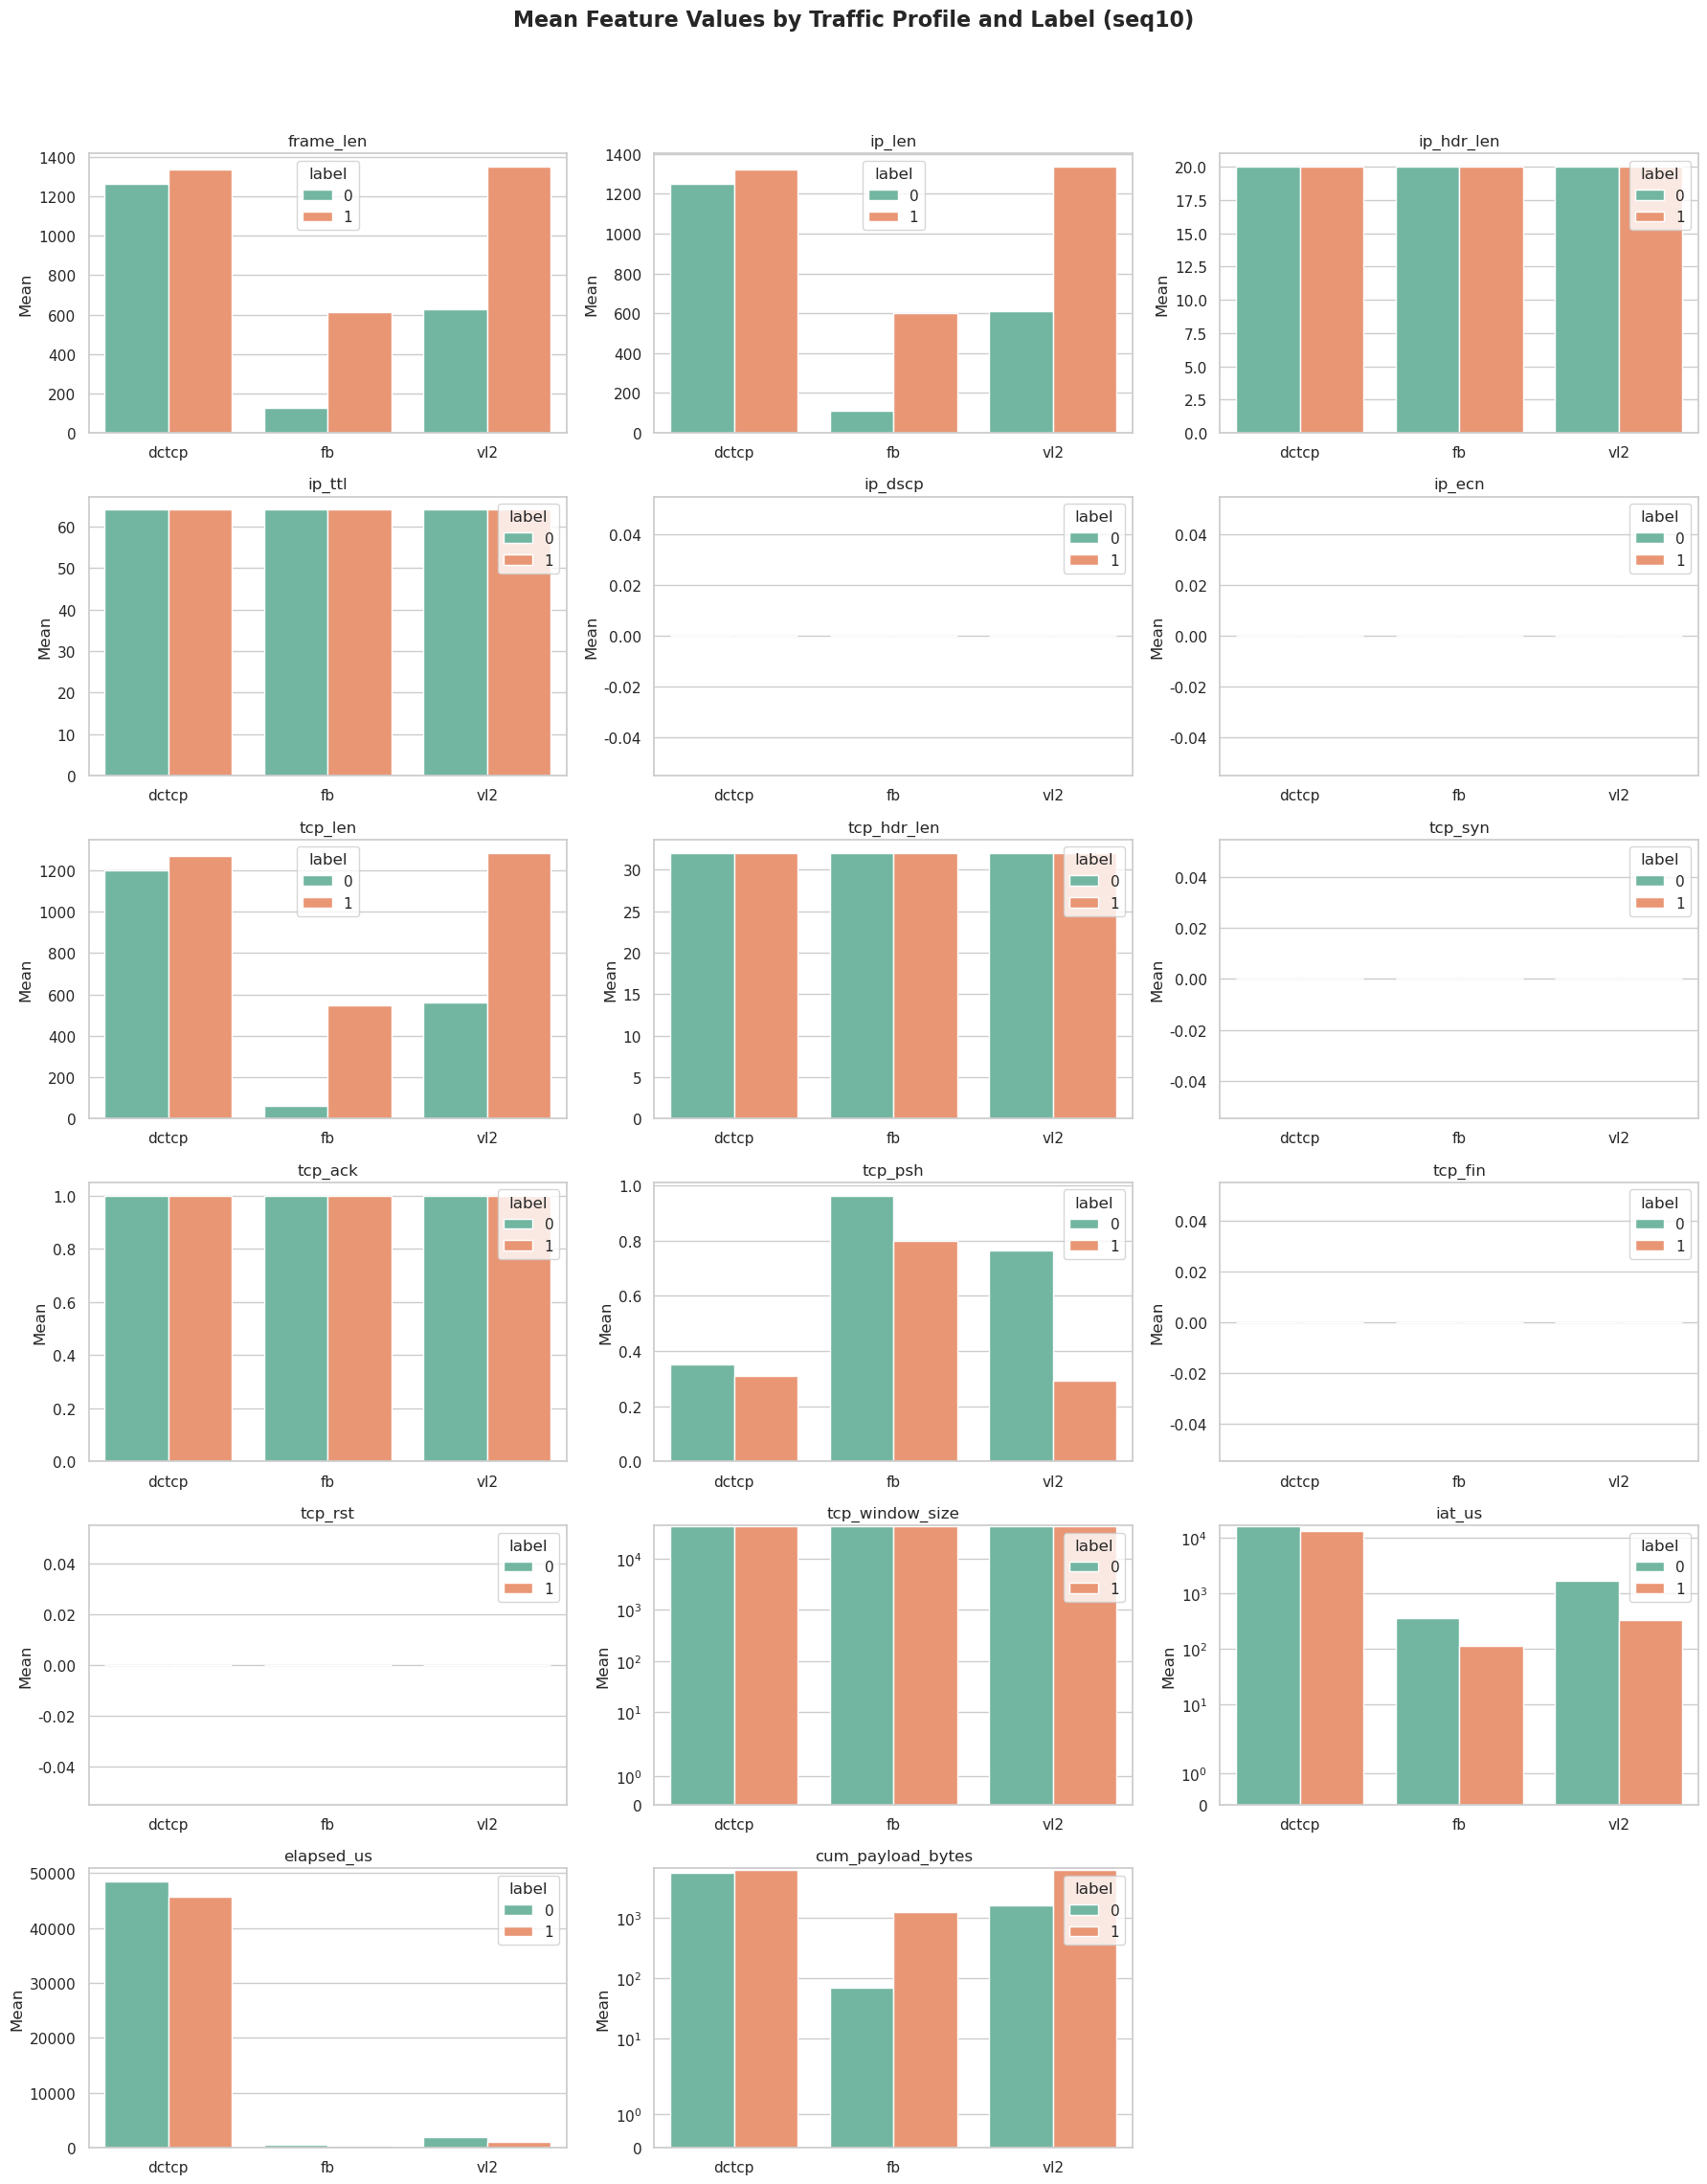

In [5]:
feature_mean_cols = [f'{name}_mean' for name in PLOT_FEATURE_NAMES]
feature_compare = all_df.groupby(['traffic_profile', 'seq_profile', 'label'])[feature_mean_cols].mean().reset_index()

plot_features = PLOT_FEATURE_NAMES[:]
cols = 3
rows = int(np.ceil(len(plot_features) / cols))

for seq_profile in SEQ_NAMES:
    subset = feature_compare[feature_compare['seq_profile'] == seq_profile]
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
    axes = np.asarray(axes).reshape(rows, cols)
    fig.suptitle(f'Mean Feature Values by Traffic Profile and Label ({seq_profile})', fontsize=16, fontweight='bold')

    for i, feature_name in enumerate(plot_features):
        ax = axes[i // cols, i % cols]
        sns.barplot(
            x='traffic_profile',
            y=f'{feature_name}_mean',
            hue='label',
            data=subset,
            ax=ax,
            palette='Set2',
        )
        if feature_name in ['iat_us', 'tcp_window_size', 'cum_payload_bytes']:
            ax.set_yscale('symlog')
        ax.set_title(feature_name)
        ax.set_xlabel('')
        ax.set_ylabel('Mean')

    for j in range(len(plot_features), rows * cols):
        axes[j // cols, j % cols].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


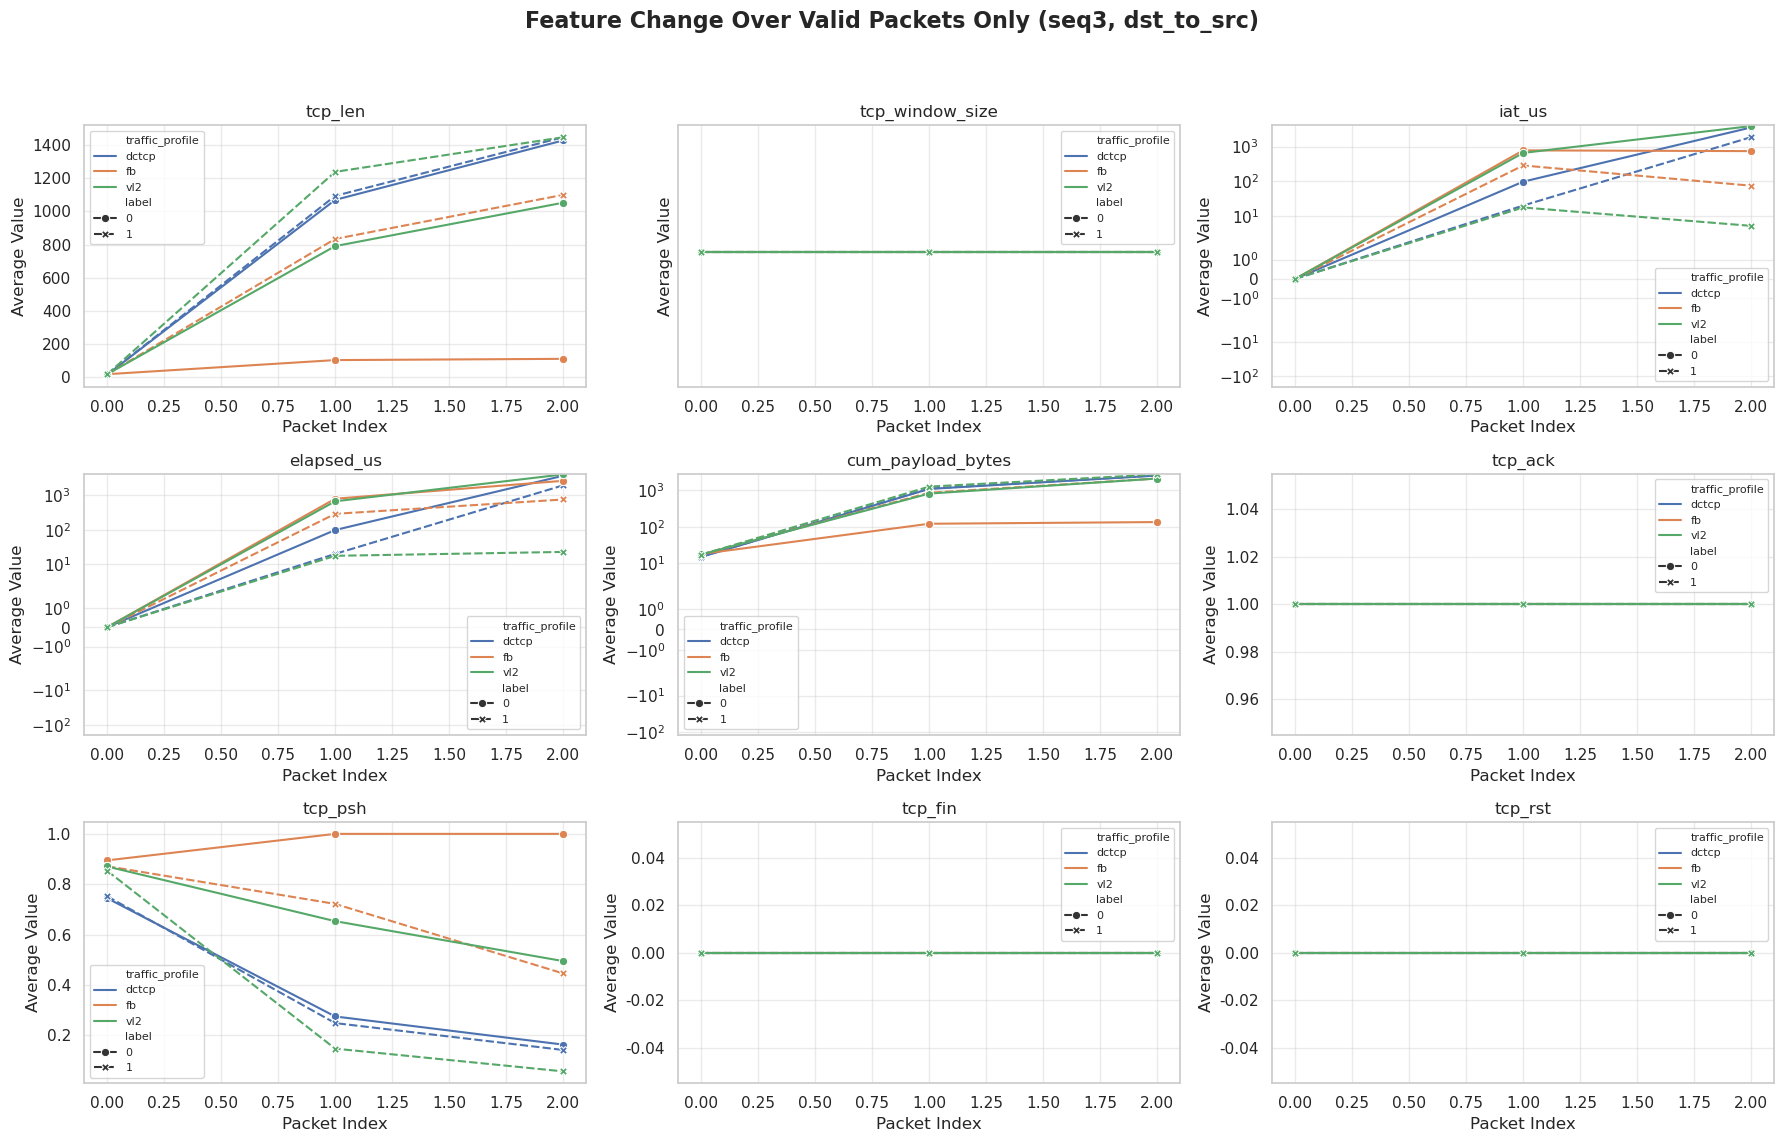

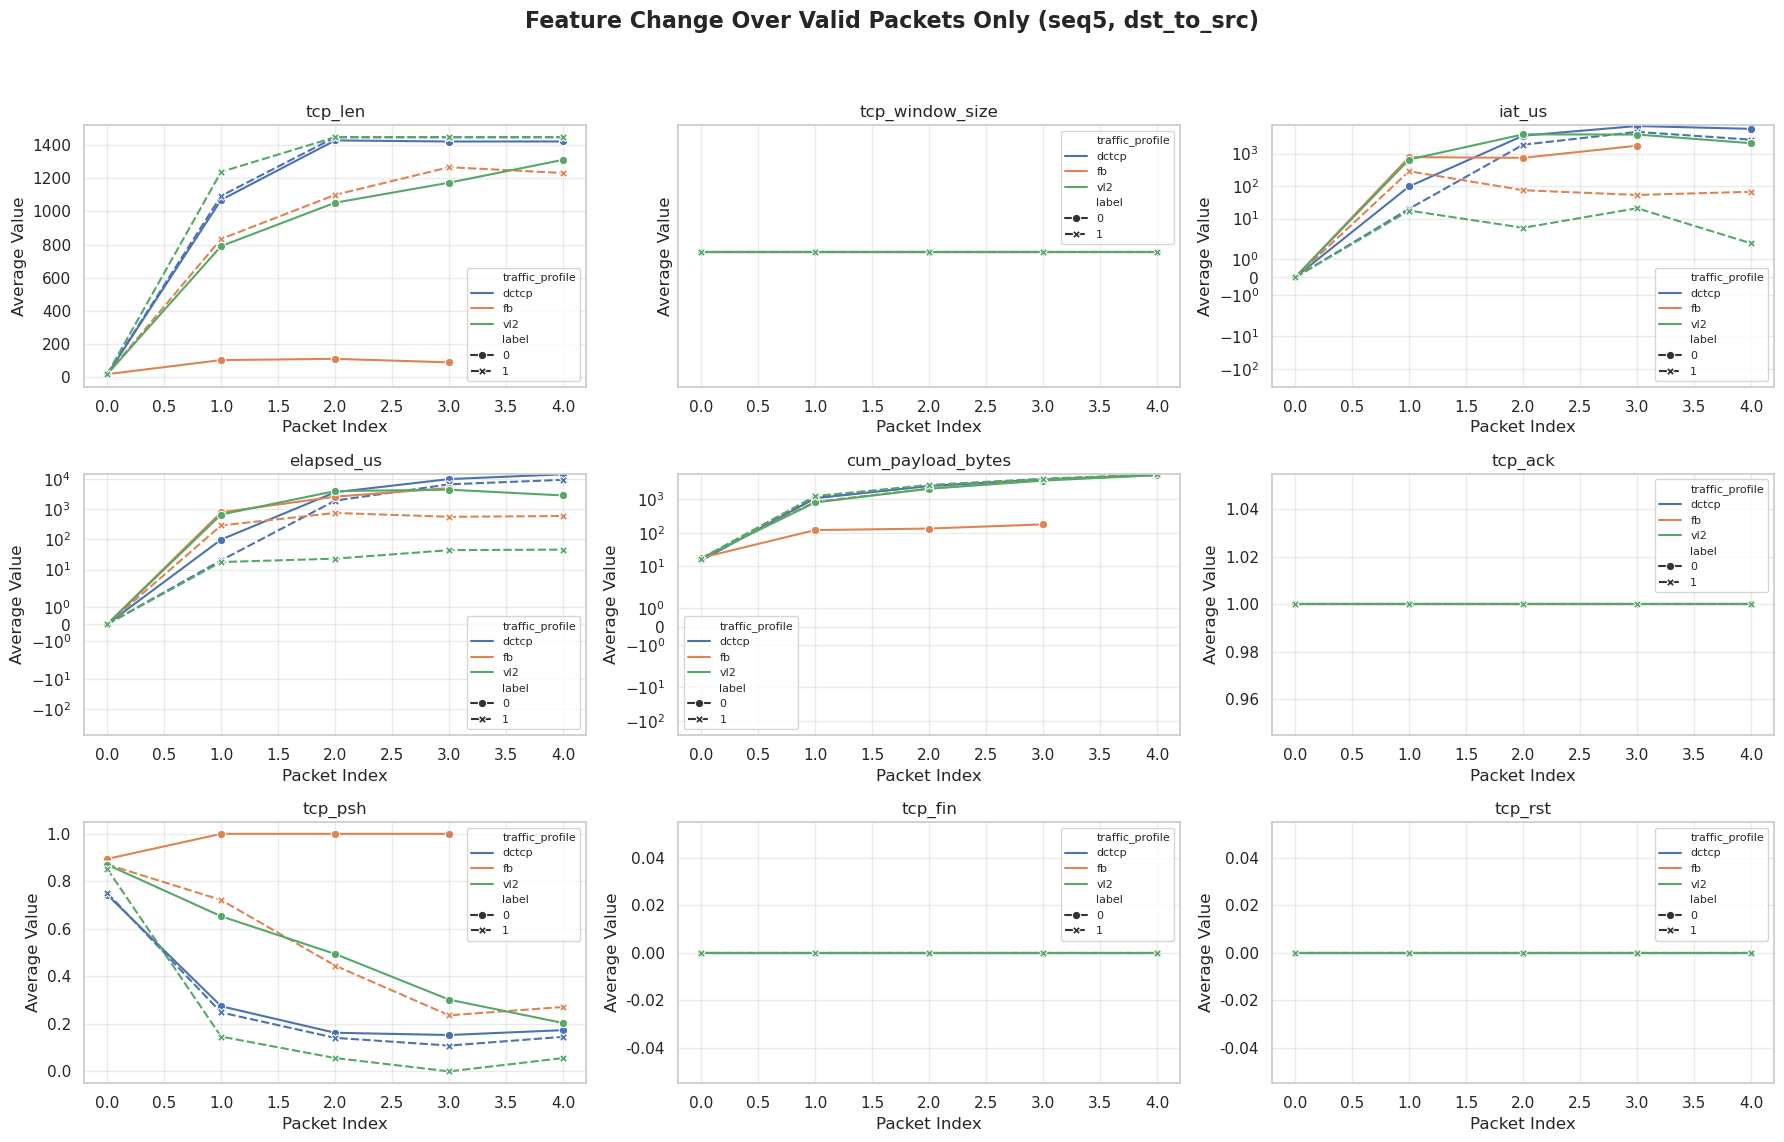

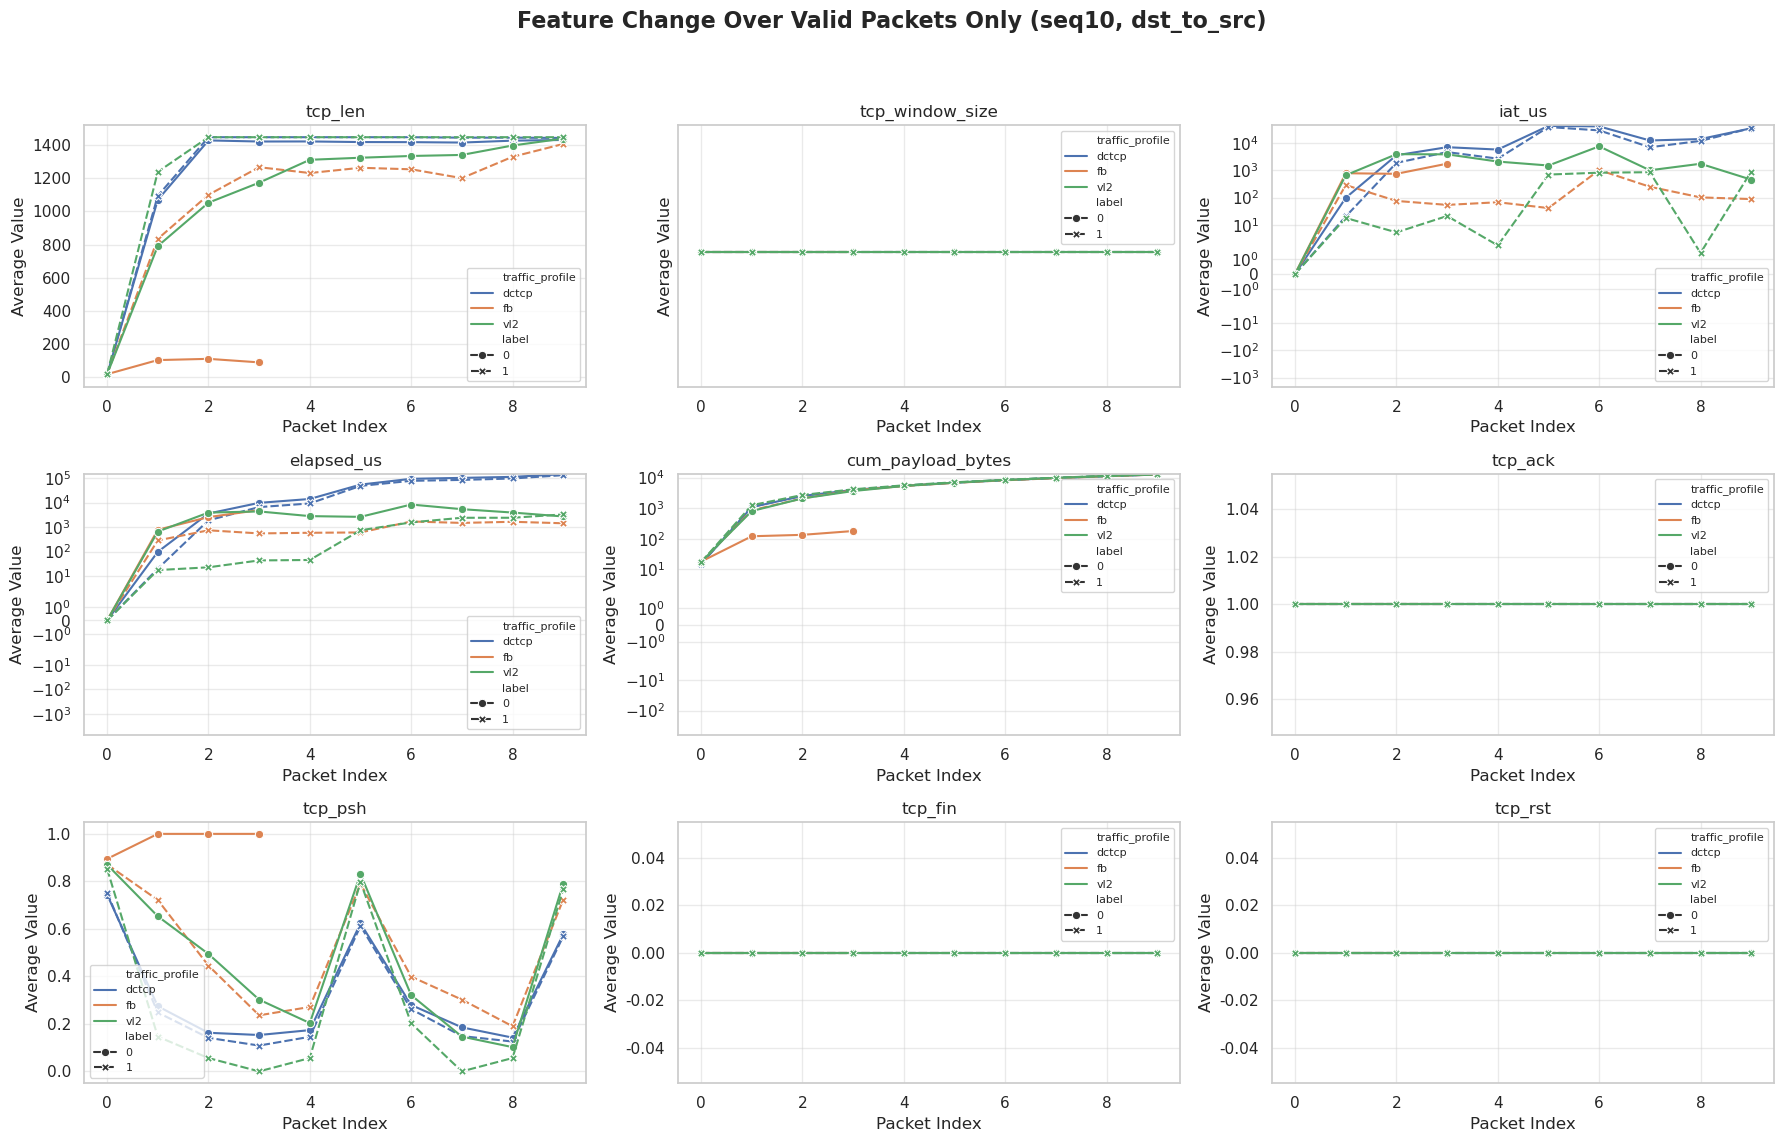

direction mix by traffic_profile/seq_profile/label:
traffic_profile  seq_profile  label  direction 
dctcp            seq10        0      dst_to_src    14399
                              1      dst_to_src     1601
                 seq3         0      dst_to_src    14399
                              1      dst_to_src     1601
                 seq5         0      dst_to_src    14399
                              1      dst_to_src     1601
fb               seq10        0      dst_to_src    14398
                              1      dst_to_src     1602
                 seq3         0      dst_to_src    14398
                              1      dst_to_src     1602
                 seq5         0      dst_to_src    14398
                              1      dst_to_src     1602
vl2              seq10        0      dst_to_src     2879
                              1      dst_to_src      321
                 seq3         0      dst_to_src     2879
                              1      dst_to_s

In [6]:
# Padding row를 제외하고, 실제 관측된 packet만 이용해 packet index별 feature 변화를 봅니다.
avg_by_label = valid_packet_df.groupby(['traffic_profile', 'seq_profile', 'label', 'packet_index'])[PLOT_FEATURE_NAMES].mean().reset_index()

line_features = [
    name for name in [
        PAYLOAD_FEATURE,
        'tcp_window_size',
        'iat_us',
        'elapsed_us',
        'cum_payload_bytes',
        'tcp_ack',
        'tcp_psh',
        'tcp_fin',
        'tcp_rst',
    ]
    if name in PLOT_FEATURE_NAMES
]

cols = 3
rows = int(np.ceil(len(line_features) / cols))

for seq_profile in SEQ_NAMES:
    subset = avg_by_label[avg_by_label['seq_profile'] == seq_profile]
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
    axes = np.asarray(axes).reshape(rows, cols)
    fig.suptitle(f'Feature Change Over Valid Packets Only ({seq_profile}, dst_to_src)', fontsize=16, fontweight='bold')

    for i, feature_name in enumerate(line_features):
        ax = axes[i // cols, i % cols]
        sns.lineplot(
            data=subset,
            x='packet_index',
            y=feature_name,
            hue='traffic_profile',
            style='label',
            markers=True,
            dashes=True,
            ax=ax,
        )
        if feature_name in ['iat_us', 'elapsed_us', 'cum_payload_bytes', 'tcp_window_size']:
            ax.set_yscale('symlog')
        ax.set_title(feature_name)
        ax.set_xlabel('Packet Index')
        ax.set_ylabel('Average Value')
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=8)

    for j in range(len(line_features), rows * cols):
        axes[j // cols, j % cols].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print('direction mix by traffic_profile/seq_profile/label:')
print(all_df.groupby(['traffic_profile', 'seq_profile', 'label', 'direction']).size())


In [7]:
summary = all_df.groupby(['traffic_profile', 'seq_profile', 'label'])[
    ['flow_size_bytes', 'directional_size_bytes', 'x_mean'] + feature_mean_cols
].agg(['mean', 'median', 'std'])
summary


flow_size_bytes                            \
                                             mean      median           std   
traffic_profile seq_profile label                                             
dctcp           seq10       0        6.897614e+05     63605.0  1.219936e+06   
                            1        1.204942e+07   8937395.0  6.984711e+06   
                seq3        0        6.897614e+05     63605.0  1.219936e+06   
                            1        1.204942e+07   8937395.0  6.984711e+06   
                seq5        0        6.897614e+05     63605.0  1.219936e+06   
                            1        1.204942e+07   8937395.0  6.984711e+06   
fb              seq10       0        1.231875e+02        52.0  1.176778e+02   
                            1        2.814734e+03       887.0  5.073466e+03   
                seq3        0        1.231875e+02        52.0  1.176778e+02   
                            1        2.814734e+03       887.0  5.073466e+03   
                seq5        0        1.231875e+02        52.0  1.176778e+02   
                            1        2.814734e+03       887.0  5.073466e+03   
vl2             seq10       0        3.093827e+04      1065.0  9.599926e+04   
                            1        1.773479e+08  26029294.0  2.862163e+08   
                seq3        0        3.093827e+04      1065.0  9.599926e+04   
                            1        1.773479e+08  26029294.0  2.862163e+08   
                seq5        0        3.093827e+04      1065.0  9.599926e+04   
                            1        1.773479e+08  26029294.0  2.862163e+08   

                                  directional_size_bytes              \
                                                    mean      median   
traffic_profile seq_profile label                                      
dctcp           seq10       0               6.897614e+05     63605.0   
                            1               1.204942e+07   8937395.0   
                seq3        0               6.897614e+05     63605.0   
                            1               1.204942e+07   8937395.0   
                seq5        0               6.897614e+05     63605.0   
                            1               1.204942e+07   8937395.0   
fb              seq10       0               1.231875e+02        52.0   
                            1               2.814734e+03       887.0   
                seq3        0               1.231875e+02        52.0   
                            1               2.814734e+03       887.0   
                seq5        0               1.231875e+02        52.0   
                            1               2.814734e+03       887.0   
vl2             seq10       0               3.093827e+04      1065.0   
                            1               1.773479e+08  26029294.0   
                seq3        0               3.093827e+04      1065.0   
                            1               1.773479e+08  26029294.0   
                seq5        0               3.093827e+04      1065.0   
                            1               1.773479e+08  26029294.0   

                                                      x_mean               \
                                            std         mean       median   
traffic_profile seq_profile label                                           
dctcp           seq10       0      1.219936e+06  6514.485809  3040.388889   
                            1      6.984711e+06  6265.520675  3040.666667   
                seq3        0      1.219936e+06  2771.443572  2675.222222   
                            1      6.984711e+06  2711.963322  2675.277778   
                seq5        0      1.219936e+06  3239.868604  2787.566667   
                            1      6.984711e+06  3059.190839  2787.622222   
fb              seq10       0      1.176778e+02  2487.186622  2456.111111   
                            1      5.073466e+03  2612.312693  2531.694444   
              

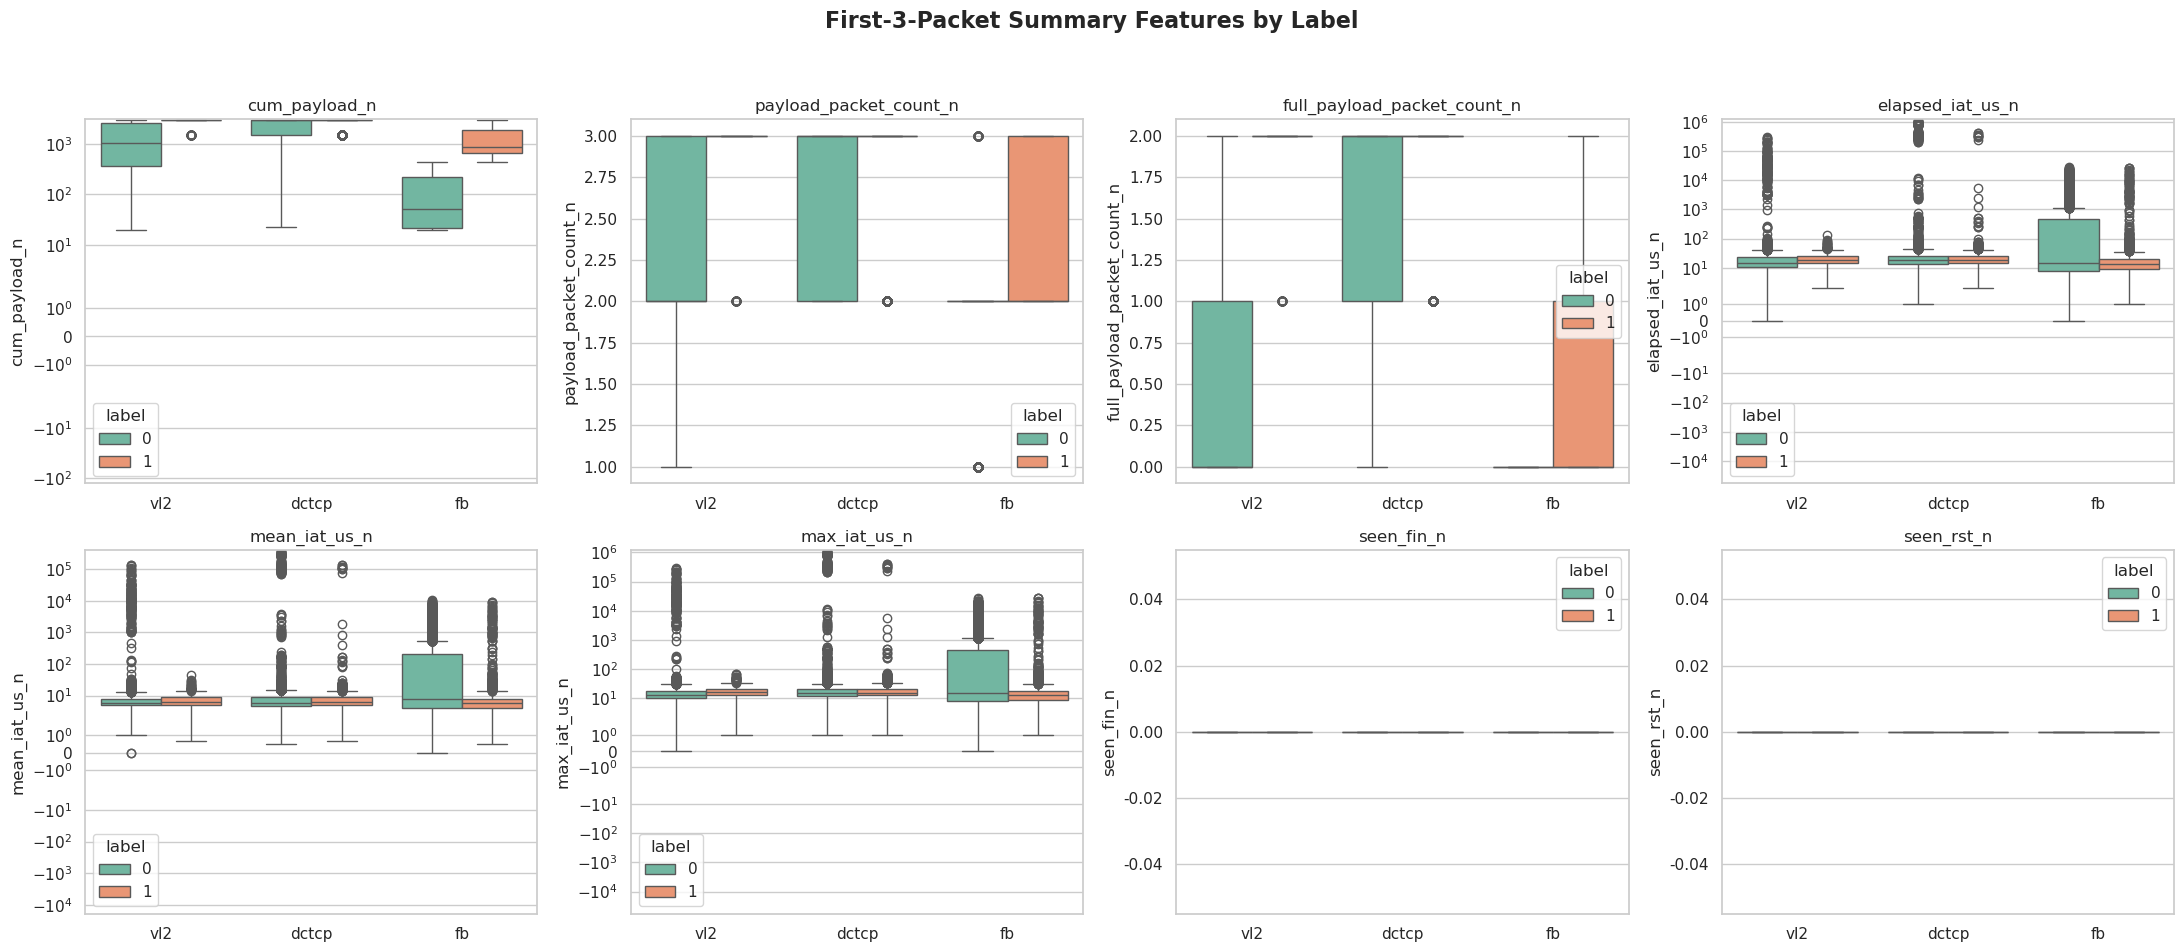

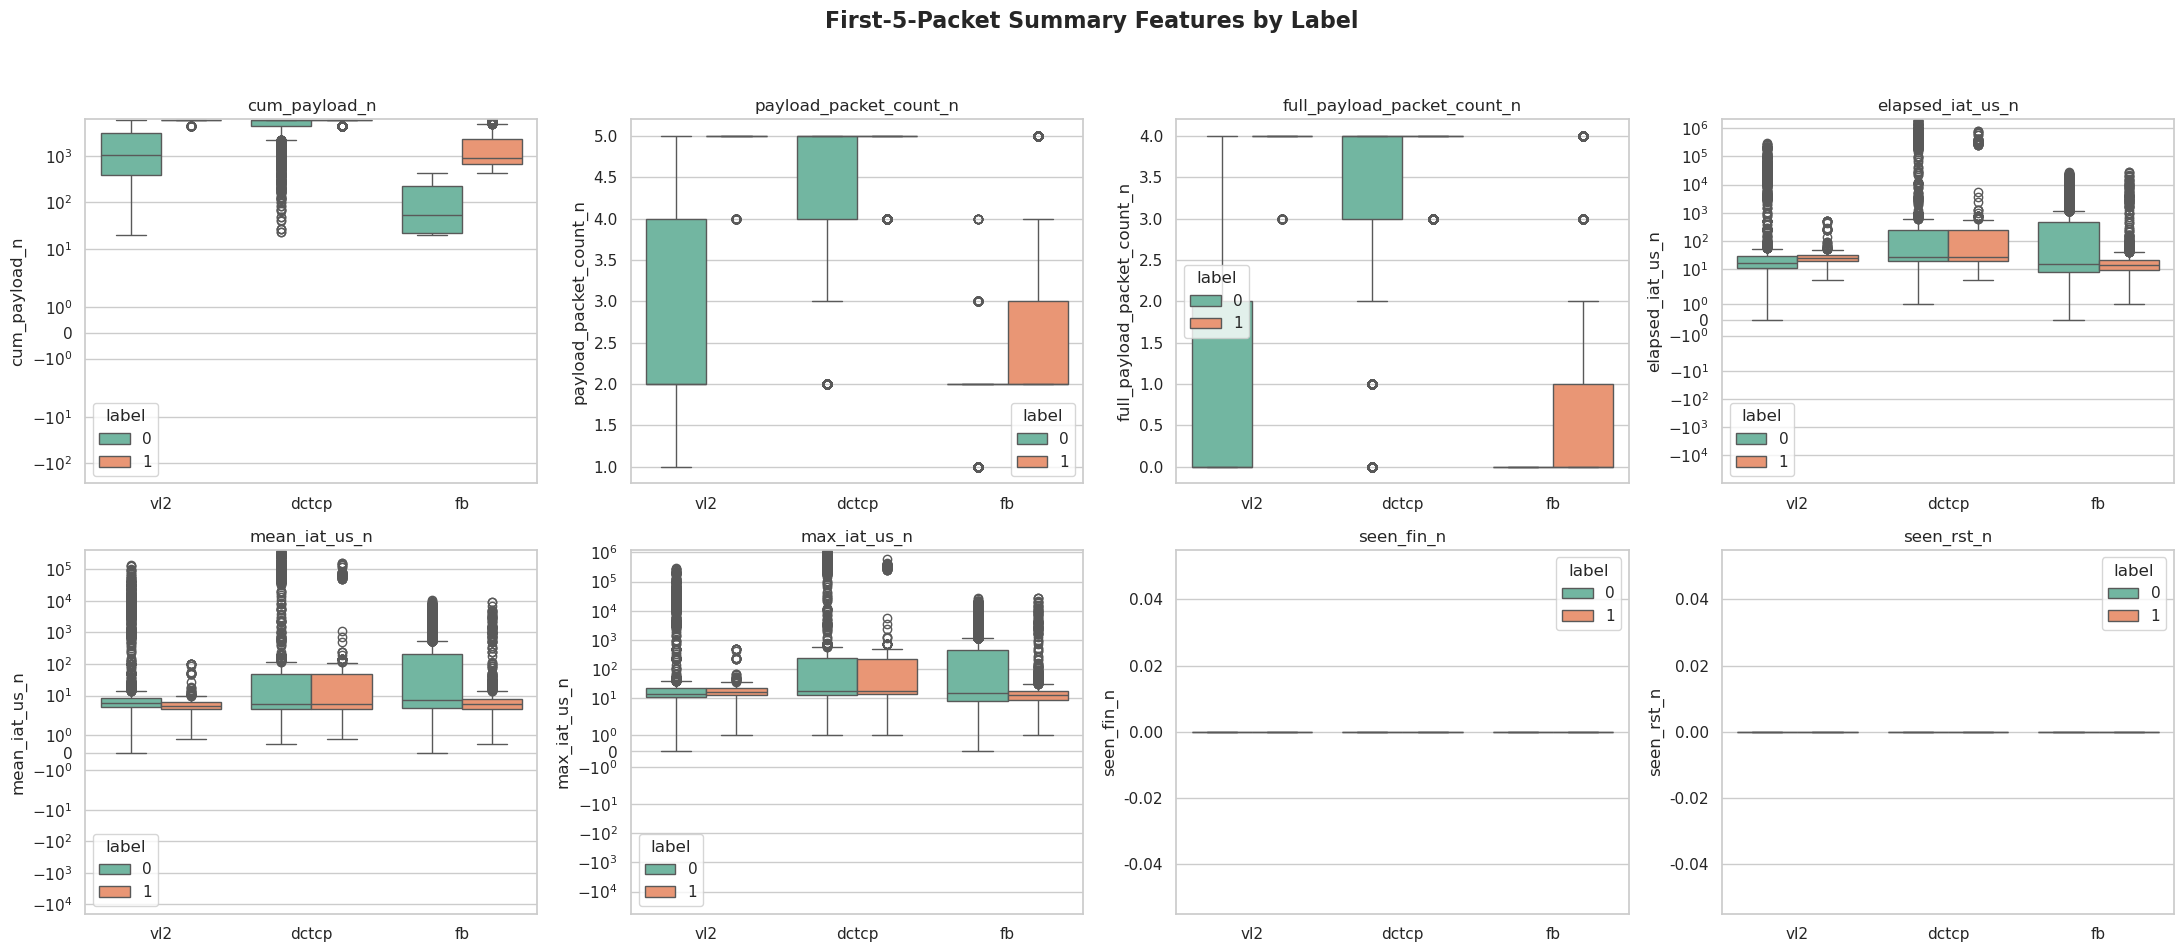

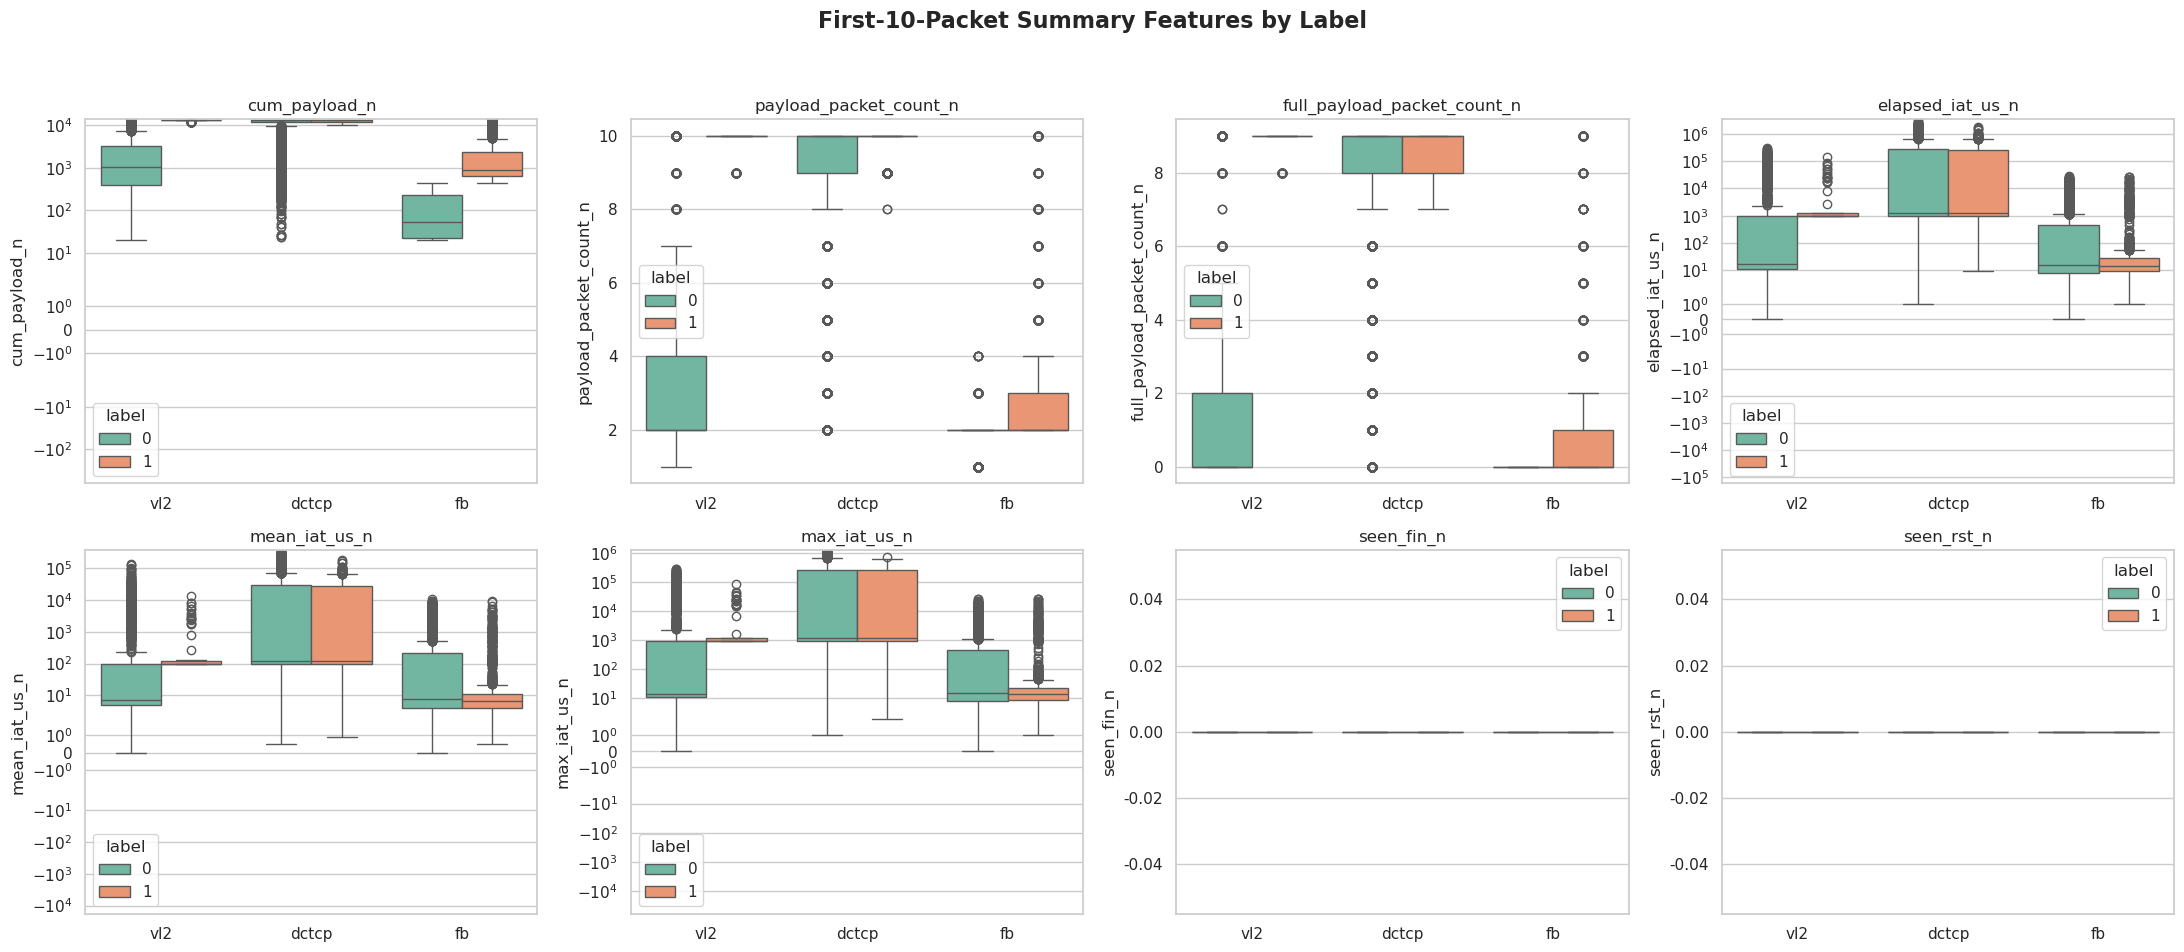

cum_payload_n                         \
                                          count          mean   median   
traffic_profile seq_profile label                                        
dctcp           seq10       0             14399  11387.710258  13052.0   
                            1              1601  12683.103061  13052.0   
                seq3        0             14399   2488.972498   2916.0   
                            1              1601   2556.939413   2916.0   
                seq5        0             14399   5193.335509   5812.0   
                            1              1601   5452.939413   5812.0   
fb              seq10       0             14398    123.187457     52.0   
                            1              1602   2410.909488    887.0   
                seq3        0             14398    123.094388     51.0   
                            1              1602   1309.747815    887.0   
                seq5        0             14398    123.187457     52.0   
                            1              1602   1834.765293    887.0   
vl2             seq10       0              2879   3125.735672   1065.0   
                            1               321  12839.987539  13052.0   
                seq3        0              2879   1358.745050   1055.0   
                            1               321   2703.987539   2916.0   
                seq5        0              2879   2046.013546   1065.0   
                            1               321   5599.987539   5812.0   

                                                    payload_packet_count_n  \
                                       min      max                  count   
traffic_profile seq_profile label                                            
dctcp           seq10       0         23.0  13052.0                  14399   
                            1      10156.0  13052.0                   1601   
                seq3        0         23.0   2916.0                  14399   
                            1       1468.0   2916.0                   1601   
                seq5        0         23.0   5812.0                  14399   
                            1       4364.0   5812.0                   1601   
fb              seq10       0         20.0    429.0                  14398   
                            1        432.0  13052.0                   1602   
                seq3        0         20.0    429.0                  14398   
                            1        432.0   2916.0                   1602   
                seq5        0         20.0    429.0                  14398   
                            1        432.0   5812.0                   1602   
vl2             seq10       0         20.0  13052.0                   2879   
                            1      11604.0  13052.0                    321   
                seq3        0         20.0   2916.0                   2879   
                            1       1468.0   2916.0                    321   
                seq5        0         20.0   5812.0                   2879   
                            1       4364.0   5812.0                    321   

                                                            ...  \
                                       mean median min max  ...   
traffic_profile seq_profile label                           ...   
dctcp           seq10       0      8.963678   10.0   2  10  ...   
                            1      9.750781   10.0   8  10  ...   
                seq3        0      2.726925    3.0   2   3  ...   
                            1      2.752030    3.0   2   3  ...   
                seq5        0      4.623863    5.0   2   5  ...   
                            1      4.752030    5.0   4   5  ...   
fb              seq10       0      1.908112    2.0   1   4  ...   
                            1      3.159176    2.0   2  10  ...   
                seq3        0      1.907070    2.0   1   3  ...   
                            1      2

In [8]:
# 초기 N개 packet 요약 feature 비교
summary_features = [
    'cum_payload_n',
    'payload_packet_count_n',
    'full_payload_packet_count_n',
    'elapsed_iat_us_n',
    'mean_iat_us_n',
    'max_iat_us_n',
    'seen_fin_n',
    'seen_rst_n',
]

for seq_profile in SEQ_NAMES:
    subset = all_df[all_df['seq_profile'] == seq_profile]
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    fig.suptitle(f'First-{seq_profile.replace("seq", "")}-Packet Summary Features by Label', fontsize=16, fontweight='bold')

    for i, feature in enumerate(summary_features):
        ax = axes[i // 4, i % 4]
        sns.boxplot(
            data=subset,
            x='traffic_profile',
            y=feature,
            hue='label',
            ax=ax,
            palette='Set2',
        )
        if feature in ['elapsed_iat_us_n', 'mean_iat_us_n', 'max_iat_us_n', 'cum_payload_n']:
            ax.set_yscale('symlog')
        ax.set_title(feature)
        ax.set_xlabel('')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

display(all_df.groupby(['traffic_profile', 'seq_profile', 'label'])[summary_features + ['flow_size_bytes', 'directional_size_bytes']].agg(['count', 'mean', 'median', 'min', 'max']))


In [9]:
# VL2에서 같은 valid payload/flag 패턴이 label 양쪽에 얼마나 섞이는지 확인
vl2_df = all_df[(all_df['traffic_profile'] == 'vl2') & (all_df['seq_profile'] == 'seq10')].copy()
vl2_packet_df = valid_packet_df[(valid_packet_df['traffic_profile'] == 'vl2') & (valid_packet_df['seq_profile'] == 'seq10')].copy()

flag_cols = [name for name in ['tcp_syn', 'tcp_ack', 'tcp_psh', 'tcp_fin', 'tcp_rst'] if name in vl2_packet_df.columns]
pattern_rows = []
for _, row in vl2_df.iterrows():
    packets = vl2_packet_df[vl2_packet_df['row_id'] == row['row_id']].sort_values('packet_index')
    pattern = tuple(
        [
            (int(packet[PAYLOAD_FEATURE]),) + tuple(int(packet[col]) for col in flag_cols)
            for _, packet in packets.iterrows()
        ]
    )
    pattern_rows.append({
        'row_id': row['row_id'],
        'seq_len': row['seq_len'],
        'label': row['label'],
        'pattern': pattern,
    })

pattern_df = pd.DataFrame(pattern_rows)
pattern_summary = (
    pattern_df
    .groupby(['seq_len', 'pattern'])
    .agg(count=('label', 'size'), label1=('label', 'sum'))
    .reset_index()
)
pattern_summary['label1_ratio'] = pattern_summary['label1'] / pattern_summary['count']

print('Top repeated valid payload/flag patterns in VL2 seq10:')
display(pattern_summary.sort_values('count', ascending=False).head(20))

print('Patterns appearing in both labels are ambiguous for feature-only classification:')
ambiguous_patterns = pattern_summary[(pattern_summary['label1_ratio'] > 0) & (pattern_summary['label1_ratio'] < 1)]
display(ambiguous_patterns.sort_values('count', ascending=False).head(20))


Top repeated valid payload/flag patterns in VL2 seq10:


,seq_len,pattern,count,label1,label1_ratio
1838,10,"((20, 0, 1, 1, 0, 0), (1448, 0, 1, 0, 0, 0), (...",528,246,0.465909
1836,10,"((0, 0, 1, 0, 0, 0), (20, 0, 1, 1, 0, 0), (144...",92,47,0.510870
1842,10,"((20, 0, 1, 1, 0, 0), (1448, 0, 1, 0, 0, 0), (...",33,18,0.545455
1837,10,"((20, 0, 1, 1, 0, 0), (1448, 0, 1, 0, 0, 0), (...",23,10,0.434783
137,2,"((20, 0, 1, 1, 0, 0), (186, 0, 1, 1, 0, 0))",11,0,0.000000
143,2,"((20, 0, 1, 1, 0, 0), (192, 0, 1, 1, 0, 0))",11,0,0.000000
131,2,"((20, 0, 1, 1, 0, 0), (180, 0, 1, 1, 0, 0))",11,0,0.000000
144,2,"((20, 0, 1, 1, 0, 0), (193, 0, 1, 1, 0, 0))",10,0,0.000000
146,2,"((20, 0, 1, 1, 0, 0), (195, 0, 1, 1, 0, 0))",9,0,0.000000
147,2,"((20, 0, 1, 1, 0, 0), (196, 0, 1, 1, 0, 0))",9,0,0.000000


Patterns appearing in both labels are ambiguous for feature-only classification:


,seq_len,pattern,count,label1,label1_ratio
1838,10,"((20, 0, 1, 1, 0, 0), (1448, 0, 1, 0, 0, 0), (...",528,246,0.465909
1836,10,"((0, 0, 1, 0, 0, 0), (20, 0, 1, 1, 0, 0), (144...",92,47,0.510870
1842,10,"((20, 0, 1, 1, 0, 0), (1448, 0, 1, 0, 0, 0), (...",33,18,0.545455
1837,10,"((20, 0, 1, 1, 0, 0), (1448, 0, 1, 0, 0, 0), (...",23,10,0.434783
